# **PHASE-I**

# **1. Threshold** **Models**



**Linear Threshold Model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 270.3
High Degree Seeds Spread: 1589.0


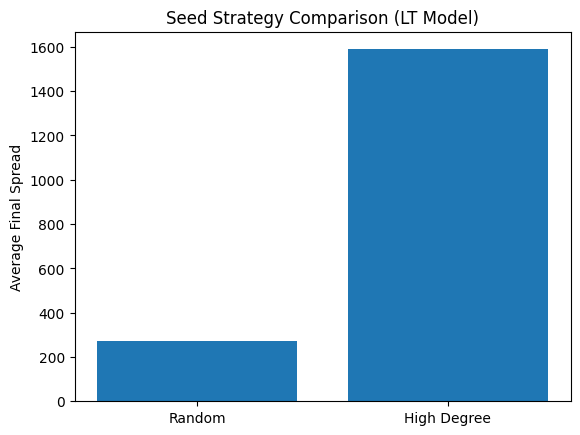

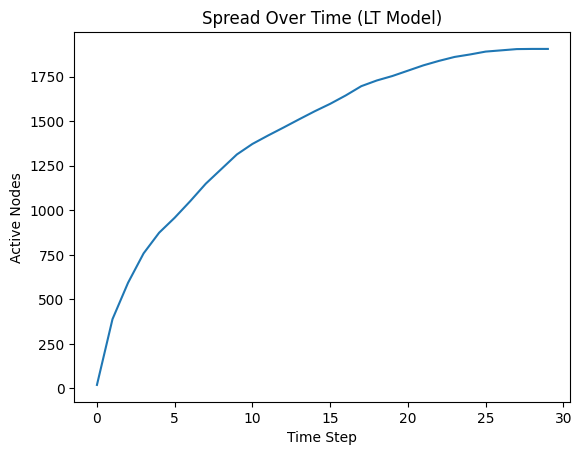

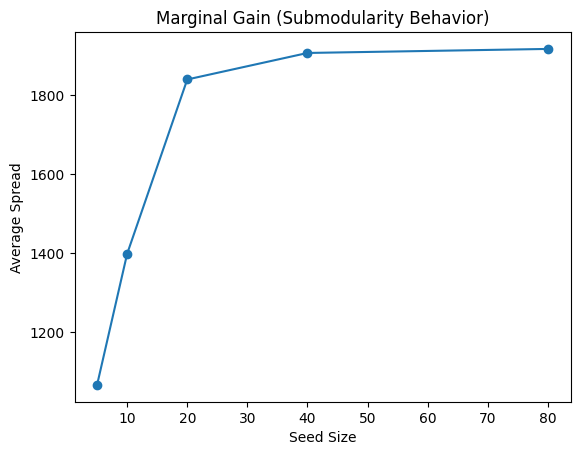

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt


def load_facebook_graph(path):
    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_weights(G):

    weights = {}

    for node in G.nodes():

        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            continue

        weight_value = 1 / len(neighbors)

        for neighbor in neighbors:
            weights[(neighbor, node)] = weight_value

    return weights




def generate_thresholds(G):

    return {node: random.random() for node in G.nodes()}




def linear_threshold(G, seeds, thresholds, weights):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in G.nodes():

            if node in active:
                continue

            influence = 0

            for neighbor in G.neighbors(node):

                if neighbor in active and (neighbor, node) in weights:

                    influence += weights[(neighbor, node)]

            if influence >= thresholds[node]:

                new_activations.add(node)

        newly_active = new_activations - active

        active.update(newly_active)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, weights, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        thresholds = generate_thresholds(G)

        active, spread = linear_threshold(G, seeds, thresholds, weights)

        spreads.append(len(active))

        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, weights, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, weights)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, weights)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()
    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])
    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (LT Model)")
    plt.show()




def visualize_spread_over_time(G, weights, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, weights, runs=1)

    spread = curves[0]

    plt.figure()
    plt.plot(spread)
    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")
    plt.title("Spread Over Time (LT Model)")
    plt.show()




def marginal_gain_analysis(G, weights):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, weights, runs=5)

        spreads.append(avg_spread)

    plt.figure()
    plt.plot(seed_sizes, spreads, marker='o')
    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")
    plt.title("Marginal Gain (Submodularity Behavior)")
    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)


    # Initialize weights once
    weights = initialize_weights(G)

    # 1️⃣ Compare Seed Strategies
    compare_seed_strategies(G, weights, k=20)

    # 2️⃣ Spread Over Time
    visualize_spread_over_time(G, weights, k=20)

    # 3️⃣ Marginal Gain Study
    marginal_gain_analysis(G, weights)

Graph Loaded
Nodes: 7115
Edges: 100762

Seed Strategy Comparison
Random Seeds Spread: 236.0
High Degree Seeds Spread: 3924.4


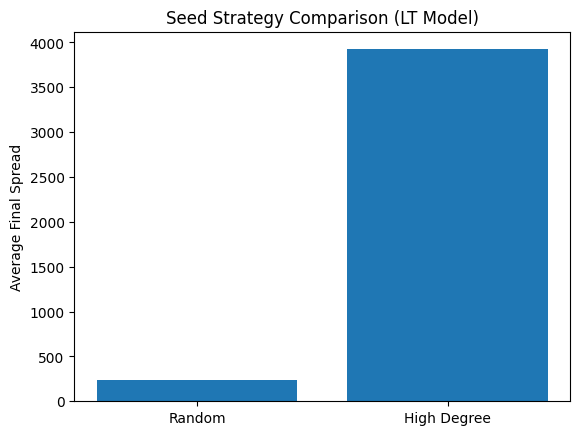

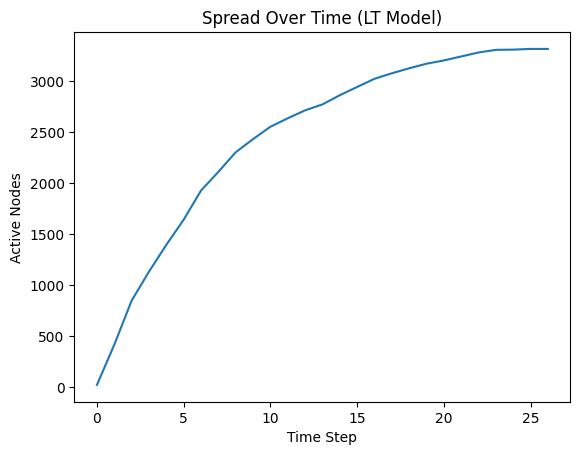

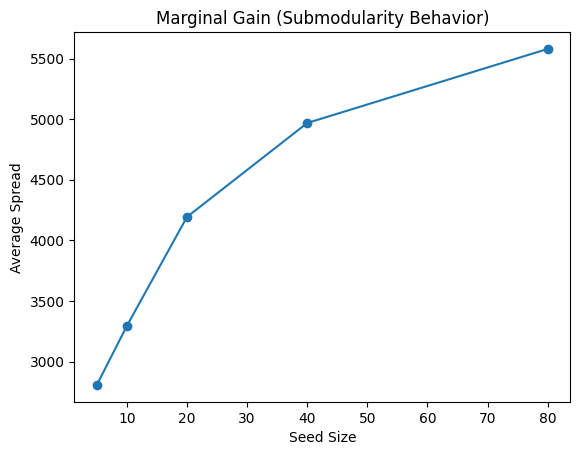

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):
    G = nx.read_edgelist(
    path,
    nodetype=int,
    comments="#",
    create_using=nx.DiGraph()
)

    G = G.to_undirected()

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_weights(G):

    weights = {}

    for node in G.nodes():

        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            continue

        weight_value = 1 / len(neighbors)

        for neighbor in neighbors:
            weights[(neighbor, node)] = weight_value

    return weights




def generate_thresholds(G):

    return {node: random.random() for node in G.nodes()}




def linear_threshold(G, seeds, thresholds, weights):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in G.nodes():

            if node in active:
                continue

            influence = 0

            for neighbor in G.neighbors(node):

                if neighbor in active and (neighbor, node) in weights:

                    influence += weights[(neighbor, node)]

            if influence >= thresholds[node]:

                new_activations.add(node)

        newly_active = new_activations - active

        active.update(newly_active)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, weights, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        thresholds = generate_thresholds(G)

        active, spread = linear_threshold(G, seeds, thresholds, weights)

        spreads.append(len(active))

        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, weights, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, weights)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, weights)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()
    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])
    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (LT Model)")
    plt.show()




def visualize_spread_over_time(G, weights, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, weights, runs=1)

    spread = curves[0]

    plt.figure()
    plt.plot(spread)
    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")
    plt.title("Spread Over Time (LT Model)")
    plt.show()




def marginal_gain_analysis(G, weights):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, weights, runs=5)

        spreads.append(avg_spread)

    plt.figure()
    plt.plot(seed_sizes, spreads, marker='o')
    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")
    plt.title("Marginal Gain (Submodularity Behavior)")
    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/Wiki-Vote.txt"

    G = load_facebook_graph(path)

    # Initialize weights once
    weights = initialize_weights(G)

    # 1️⃣ Compare Seed Strategies
    compare_seed_strategies(G, weights, k=20)

    # 2️⃣ Spread Over Time
    visualize_spread_over_time(G, weights, k=20)

    # 3️⃣ Marginal Gain Study
    marginal_gain_analysis(G, weights)

**Majority Threshold Model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 20.0
High Degree Seeds Spread: 162.0


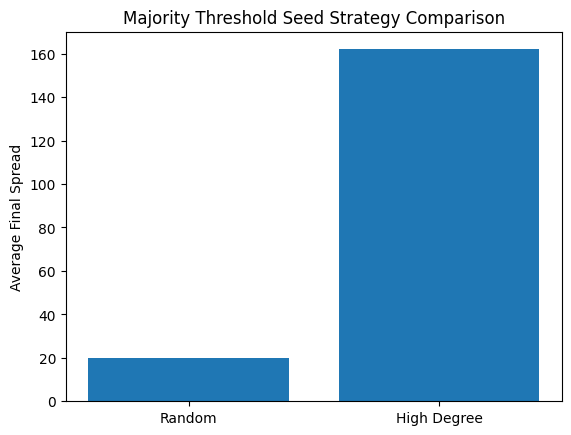

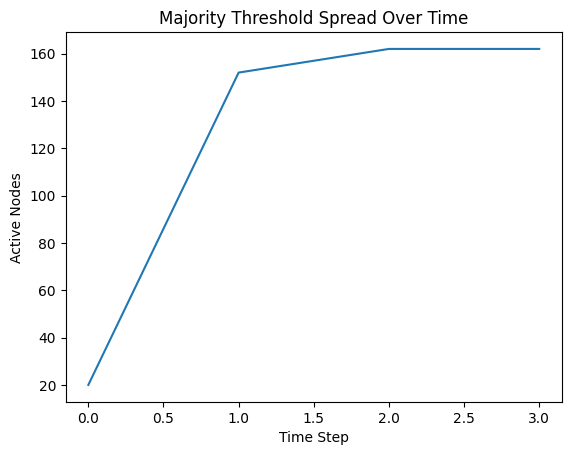

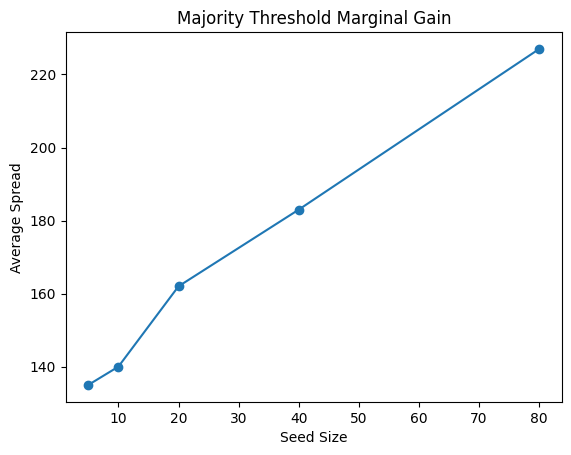

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):
    G = nx.read_edgelist(path, nodetype=int)
    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G




def majority_threshold(G, seeds):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in G.nodes():

            if node in active:
                continue

            neighbors = list(G.neighbors(node))

            if len(neighbors) == 0:
                continue

            active_neighbors = sum(1 for n in neighbors if n in active)

            # Majority condition
            if active_neighbors / len(neighbors) >= 0.5:
                new_activations.add(node)

        newly_active = new_activations - active
        active.update(newly_active)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):
    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):
    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)
    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = majority_threshold(G, seeds)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()
    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])
    plt.ylabel("Average Final Spread")
    plt.title("Majority Threshold Seed Strategy Comparison")
    plt.show()




def visualize_spread_over_time(G, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, runs=1)

    spread = curves[0]

    plt.figure()
    plt.plot(spread)
    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")
    plt.title("Majority Threshold Spread Over Time")
    plt.show()




def marginal_gain_analysis(G):

    seed_sizes = [5, 10, 20, 40, 80]
    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)
        avg_spread, _ = monte_carlo_simulation(G, seeds, runs=5)

        spreads.append(avg_spread)

    plt.figure()
    plt.plot(seed_sizes, spreads, marker='o')
    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")
    plt.title("Majority Threshold Marginal Gain")
    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)

    # 1️⃣ Compare Seed Strategies
    compare_seed_strategies(G, k=20)

    # 2️⃣ Spread Over Time
    visualize_spread_over_time(G, k=20)

    # 3️⃣ Marginal Gain Study
    marginal_gain_analysis(G)

**Small Threshold Model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 53.0
High Degree Seeds Spread: 1749.0


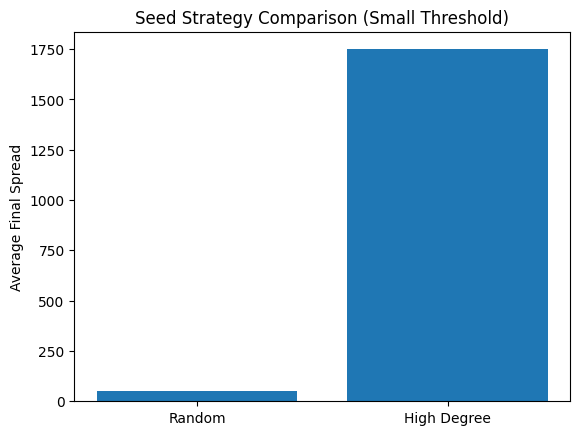

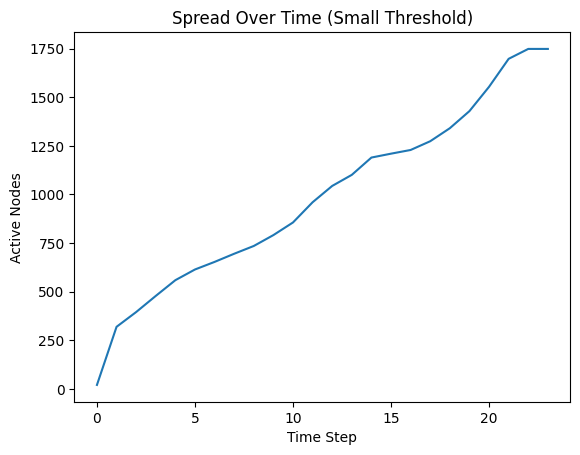

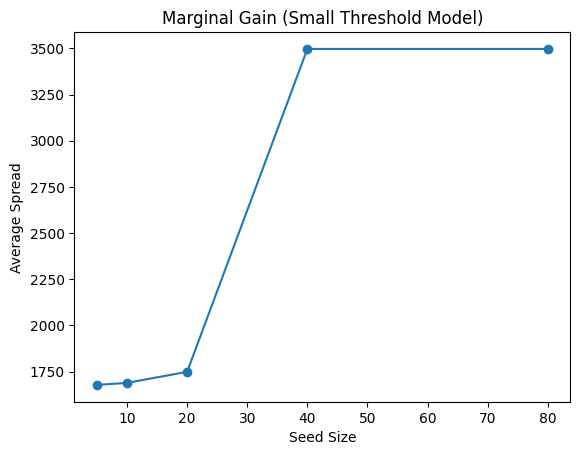

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):
    G = nx.read_edgelist(path, nodetype=int)
    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G




def initialize_weights(G):

    weights = {}

    for node in G.nodes():

        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            continue

        weight_value = 1 / len(neighbors)

        for neighbor in neighbors:
            weights[(neighbor, node)] = weight_value

    return weights




def generate_thresholds(G, threshold_value):

    return {node: threshold_value for node in G.nodes()}




def small_threshold_diffusion(G, seeds, thresholds, weights):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in G.nodes():

            if node in active:
                continue

            influence = 0

            for neighbor in G.neighbors(node):

                if neighbor in active and (neighbor, node) in weights:
                    influence += weights[(neighbor, node)]

            if influence >= thresholds[node]:
                new_activations.add(node)

        newly_active = new_activations - active
        active.update(newly_active)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):
    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, weights, threshold_value=0.22, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        thresholds = generate_thresholds(G, threshold_value)

        active, spread = small_threshold_diffusion(G, seeds, thresholds, weights)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, weights, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, weights)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, weights)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()
    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])
    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Small Threshold)")
    plt.show()




def visualize_spread_over_time(G, weights, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, weights, runs=1)

    spread = curves[0]

    plt.figure()
    plt.plot(spread)
    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")
    plt.title("Spread Over Time (Small Threshold)")
    plt.show()




def marginal_gain_analysis(G, weights):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, weights)

        spreads.append(avg_spread)

    plt.figure()
    plt.plot(seed_sizes, spreads, marker='o')
    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")
    plt.title("Marginal Gain (Small Threshold Model)")
    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)

    # Initialize weights once
    weights = initialize_weights(G)

    compare_seed_strategies(G, weights, k=20)

    visualize_spread_over_time(G, weights, k=20)

    marginal_gain_analysis(G, weights)

**Unanimous Threshold Model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 20.0
High Degree Seeds Spread: 73.0


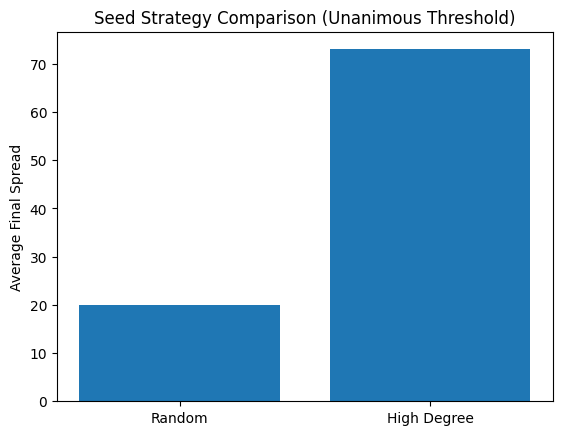

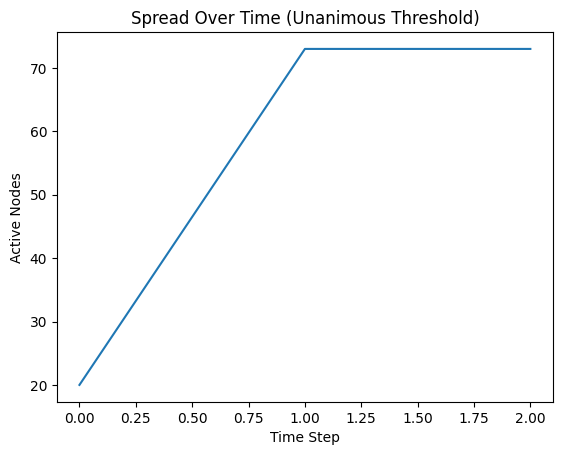

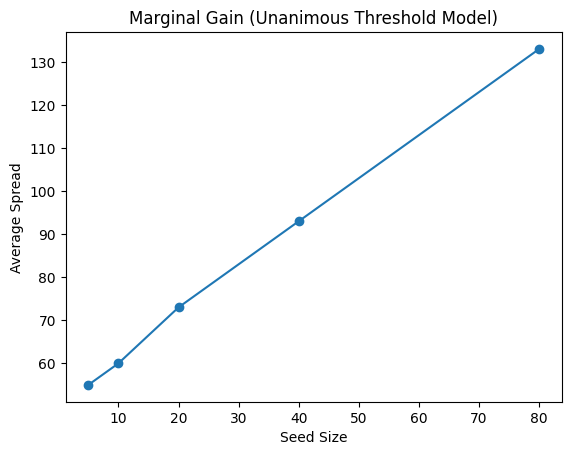

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def unanimous_threshold_diffusion(G, seeds):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in G.nodes():

            if node in active:
                continue

            neighbors = list(G.neighbors(node))

            if len(neighbors) == 0:
                continue

            active_neighbors = sum(1 for n in neighbors if n in active)

            if active_neighbors == len(neighbors):
                new_activations.add(node)

        newly_active = new_activations - active
        active.update(newly_active)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = unanimous_threshold_diffusion(G, seeds)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()

    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])

    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Unanimous Threshold)")

    plt.show()




def visualize_spread_over_time(G, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, runs=1)

    spread = curves[0]

    plt.figure()

    plt.plot(spread)

    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")

    plt.title("Spread Over Time (Unanimous Threshold)")

    plt.show()




def marginal_gain_analysis(G):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds)

        spreads.append(avg_spread)

    plt.figure()

    plt.plot(seed_sizes, spreads, marker='o')

    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")

    plt.title("Marginal Gain (Unanimous Threshold Model)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)


    compare_seed_strategies(G, k=20)


    visualize_spread_over_time(G, k=20)


    marginal_gain_analysis(G)

# **2. Cascading Models**

**Independent Cascading Model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 2171.8
High Degree Seeds Spread: 2296.8


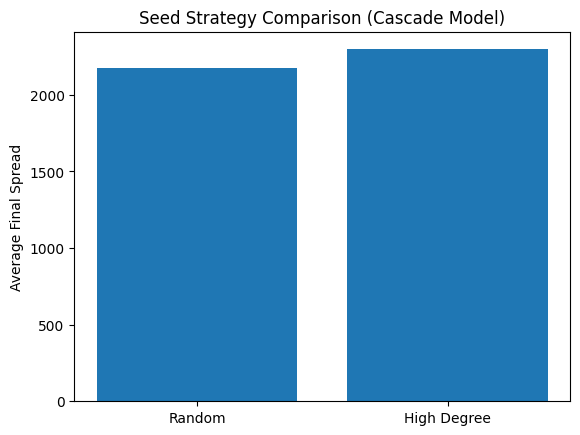

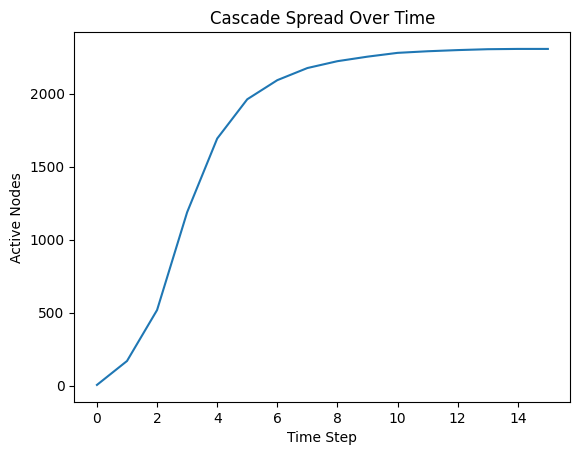

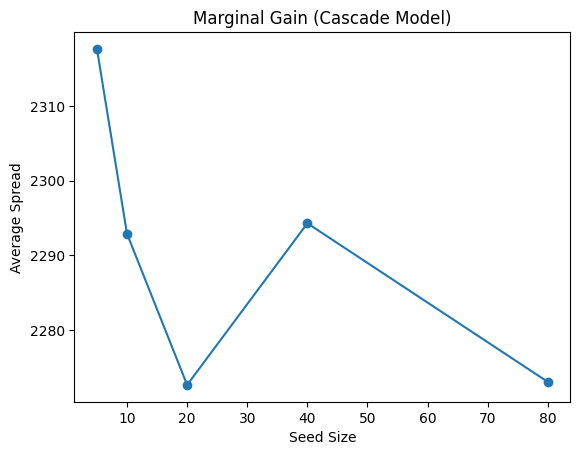

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_edge_probabilities(G):

    edge_prob = {}

    for u, v in G.edges():

        p = random.uniform(0.01, 0.1)

        edge_prob[(u, v)] = p
        edge_prob[(v, u)] = p

    return edge_prob




def independent_cascade(G, seeds, edge_prob):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in newly_active:

            for neighbor in G.neighbors(node):

                if neighbor not in active:

                    p = edge_prob[(node, neighbor)]

                    if random.random() < p:
                        new_activations.add(neighbor)

        newly_active = new_activations
        active.update(new_activations)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]



def monte_carlo_simulation(G, seeds, edge_prob, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = independent_cascade(G, seeds, edge_prob)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, edge_prob, k=5):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, edge_prob)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, edge_prob)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()

    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])

    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Cascade Model)")

    plt.show()




def visualize_spread_over_time(G, edge_prob, k=5):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, edge_prob, runs=1)

    spread = curves[0]

    plt.figure()

    plt.plot(spread)

    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")

    plt.title("Cascade Spread Over Time")

    plt.show()




def marginal_gain_analysis(G, edge_prob):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, edge_prob)

        spreads.append(avg_spread)

    plt.figure()

    plt.plot(seed_sizes, spreads, marker='o')

    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")

    plt.title("Marginal Gain (Cascade Model)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)

    # initialize edge probabilities
    edge_prob = initialize_edge_probabilities(G)

    compare_seed_strategies(G, edge_prob, k=5)

    visualize_spread_over_time(G, edge_prob, k=5)

    marginal_gain_analysis(G, edge_prob)

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 1822.1
High Degree Seeds Spread: 2183.7


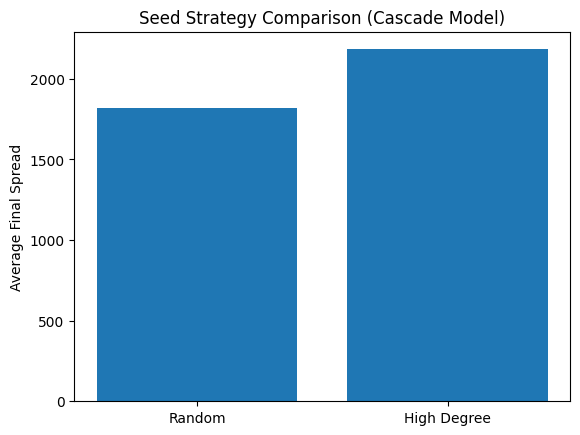

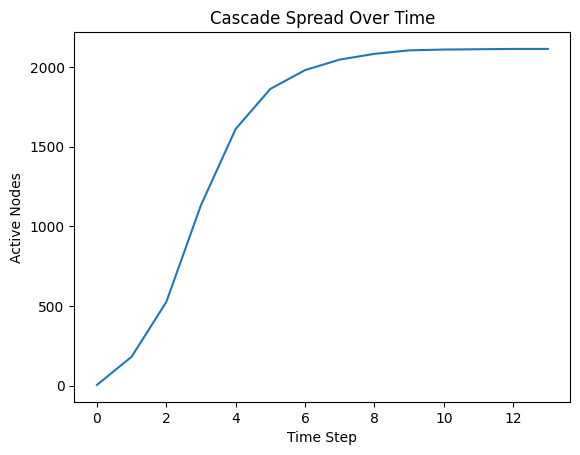

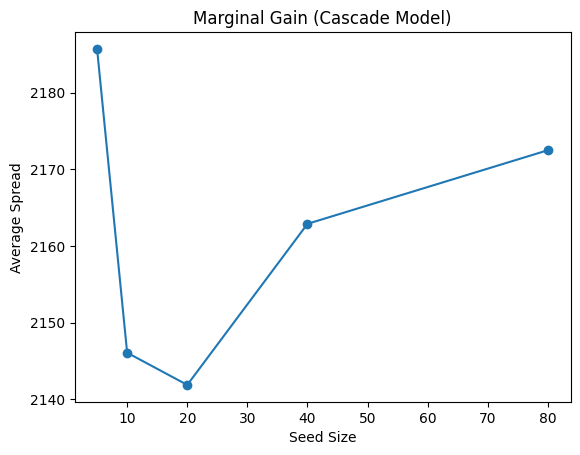

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def independent_cascade(G, seeds, p=0.05):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in newly_active:

            for neighbor in G.neighbors(node):

                if neighbor not in active:

                    if random.random() < p:
                        new_activations.add(neighbor)

        newly_active = new_activations
        active.update(new_activations)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = independent_cascade(G, seeds)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, k=5):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()

    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])

    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Cascade Model)")

    plt.show()




def visualize_spread_over_time(G, k=5):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, runs=1)

    spread = curves[0]

    plt.figure()

    plt.plot(spread)

    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")

    plt.title("Cascade Spread Over Time")

    plt.show()




def marginal_gain_analysis(G):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds)

        spreads.append(avg_spread)

    plt.figure()

    plt.plot(seed_sizes, spreads, marker='o')

    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")

    plt.title("Marginal Gain (Cascade Model)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)


    compare_seed_strategies(G, k=5)


    visualize_spread_over_time(G, k=5)


    marginal_gain_analysis(G)

Graph Loaded
Nodes: 7115
Edges: 100762

Seed Strategy Comparison
Random Seeds Spread: 839.1
High Degree Seeds Spread: 2775.5


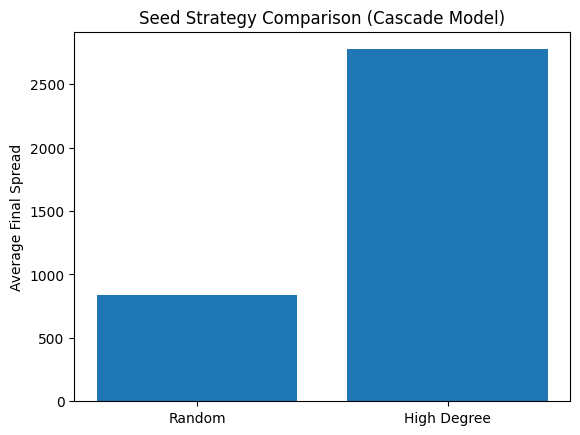

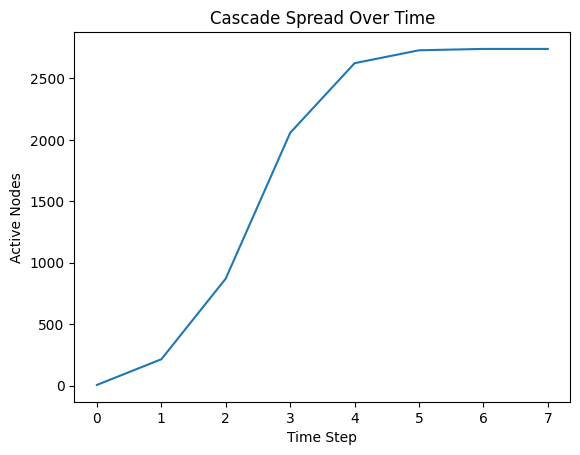

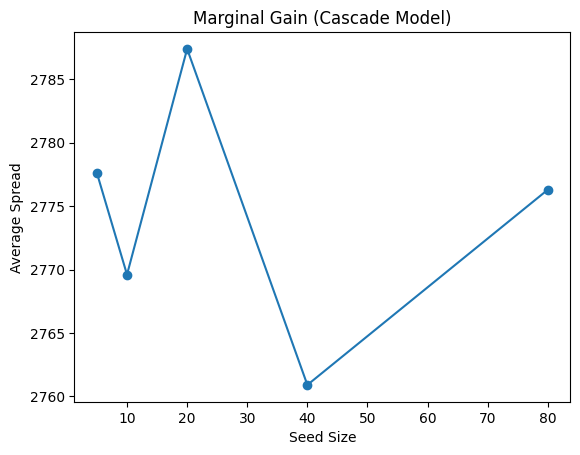

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):

    G = nx.read_edgelist(
    path,
    nodetype=int,
    comments="#",
    create_using=nx.DiGraph()
)

    G = G.to_undirected()

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_edge_probabilities(G):

    edge_prob = {}

    for u, v in G.edges():

        p = random.uniform(0.01, 0.1)

        edge_prob[(u, v)] = p
        edge_prob[(v, u)] = p

    return edge_prob




def independent_cascade(G, seeds, edge_prob):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    while newly_active:

        new_activations = set()

        for node in newly_active:

            for neighbor in G.neighbors(node):

                if neighbor not in active:

                    p = edge_prob[(node, neighbor)]

                    if random.random() < p:
                        new_activations.add(neighbor)

        newly_active = new_activations
        active.update(new_activations)

        spread_over_time.append(len(active))

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, edge_prob, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = independent_cascade(G, seeds, edge_prob)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, edge_prob, k=5):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, edge_prob)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, edge_prob)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()

    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])

    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Cascade Model)")

    plt.show()




def visualize_spread_over_time(G, edge_prob, k=5):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, edge_prob, runs=1)

    spread = curves[0]

    plt.figure()

    plt.plot(spread)

    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")

    plt.title("Cascade Spread Over Time")

    plt.show()



def marginal_gain_analysis(G, edge_prob):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, edge_prob)

        spreads.append(avg_spread)

    plt.figure()

    plt.plot(seed_sizes, spreads, marker='o')

    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")

    plt.title("Marginal Gain (Cascade Model)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/Wiki-Vote.txt"

    G = load_facebook_graph(path)

    # initialize edge probabilities
    edge_prob = initialize_edge_probabilities(G)

    compare_seed_strategies(G, edge_prob, k=5)

    visualize_spread_over_time(G, edge_prob, k=5)

    marginal_gain_analysis(G, edge_prob)

**Decreasing Cascading model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 1289.2
High Degree Seeds Spread: 2399.9


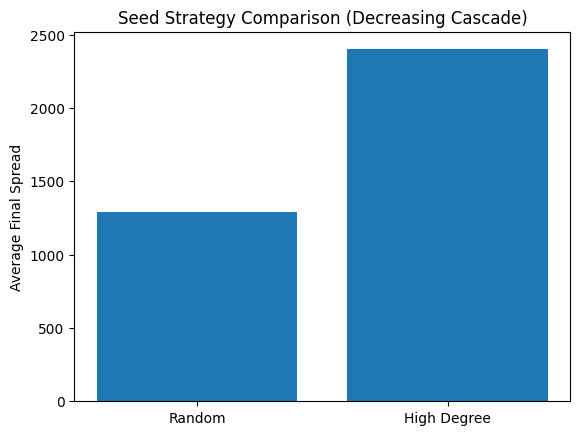

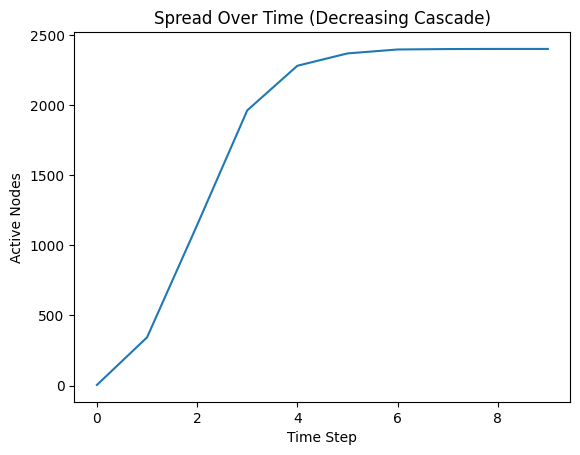

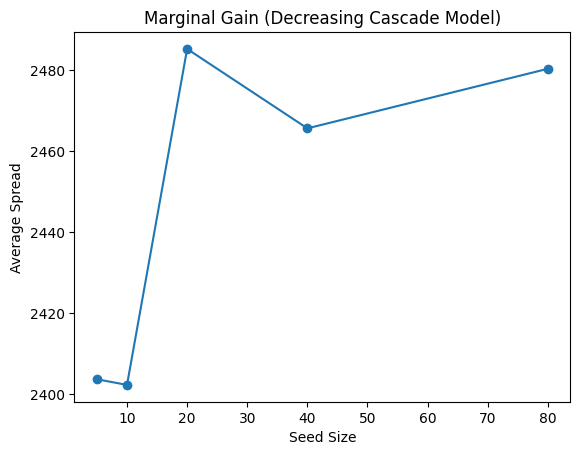

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt



def load_facebook_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def decreasing_cascade(G, seeds, p0=0.1, decay=0.8):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    t = 0

    while newly_active:

        new_activations = set()

        p = p0 * (decay ** t)

        for node in newly_active:

            for neighbor in G.neighbors(node):

                if neighbor not in active:

                    if random.random() < p:
                        new_activations.add(neighbor)

        newly_active = new_activations
        active.update(new_activations)

        spread_over_time.append(len(active))

        t += 1

    return active, spread_over_time




def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]




def monte_carlo_simulation(G, seeds, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = decreasing_cascade(G, seeds)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves




def compare_seed_strategies(G, k):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()

    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])

    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Decreasing Cascade)")

    plt.show()




def visualize_spread_over_time(G, k):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, runs=1)

    spread = curves[0]

    plt.figure()

    plt.plot(spread)

    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")

    plt.title("Spread Over Time (Decreasing Cascade)")

    plt.show()




def marginal_gain_analysis(G):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds)

        spreads.append(avg_spread)

    plt.figure()

    plt.plot(seed_sizes, spreads, marker='o')

    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")

    plt.title("Marginal Gain (Decreasing Cascade Model)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)

    compare_seed_strategies(G, k=5)

    visualize_spread_over_time(G, k=5)

    marginal_gain_analysis(G)

**Generalised cascading model**

Graph Loaded
Nodes: 4039
Edges: 88234

Seed Strategy Comparison
Random Seeds Spread: 329.6
High Degree Seeds Spread: 465.7


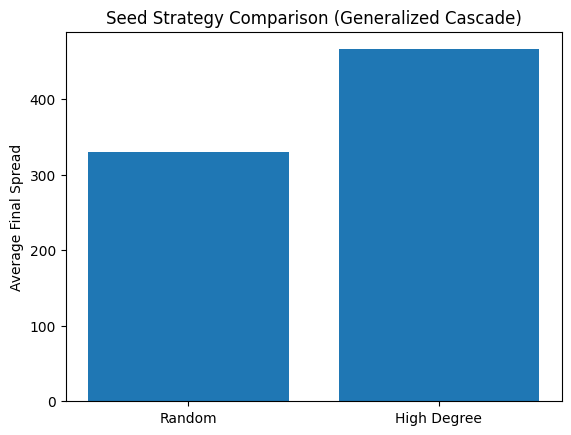

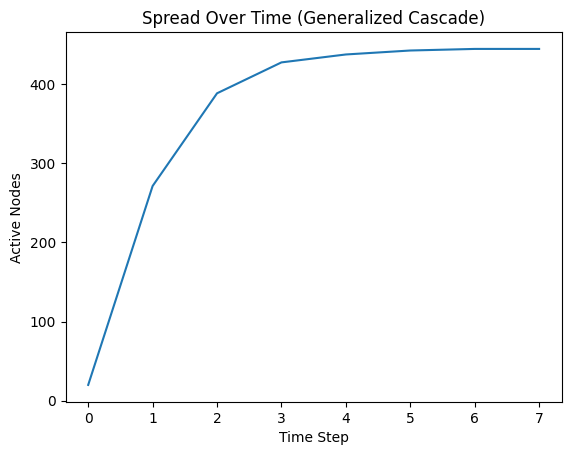

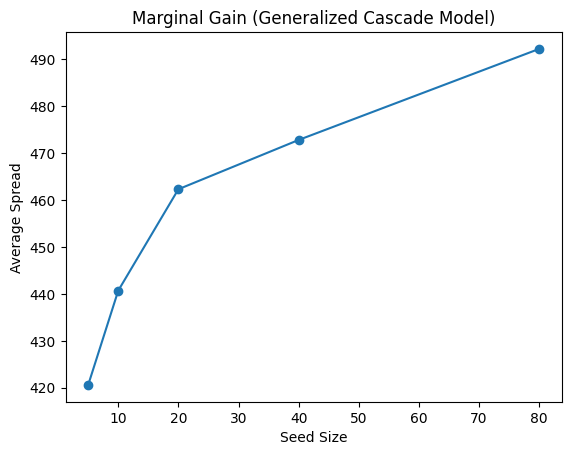

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt


def load_facebook_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Graph Loaded")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G


# Base edge probabilities
def assign_edge_probabilities(G):

    prob = {}

    for u, v in G.edges():

        p = random.uniform(0.01, 0.1)

        prob[(u, v)] = p
        prob[(v, u)] = p

    return prob


# Generalized Cascade Model
def generalized_cascade(G, seeds, prob):

    active = set(seeds)
    newly_active = set(seeds)

    spread_over_time = [len(active)]

    # Track failed attempts S for each node
    failed_attempts = {node: set() for node in G.nodes()}

    while newly_active:

        new_activations = set()

        for x in newly_active:

            for y in G.neighbors(x):

                if y not in active:

                    S = failed_attempts[y]

                    base_p = prob.get((x, y), 0)

                    # Conditional probability Py(x|S)
                    p = base_p / (1 + len(S))

                    if random.random() < p:

                        new_activations.add(y)

                    else:

                        S.add(x)   # record failed attempt

        newly_active = new_activations
        active.update(new_activations)

        spread_over_time.append(len(active))

    return active, spread_over_time


def random_seeds(G, k):

    return random.sample(list(G.nodes()), k)


def high_degree_seeds(G, k):

    degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)

    return [node for node, _ in degree_sorted[:k]]


def monte_carlo_simulation(G, seeds, prob, runs=10):

    spreads = []
    curves = []

    for _ in range(runs):

        active, spread = generalized_cascade(G, seeds, prob)

        spreads.append(len(active))
        curves.append(spread)

    return np.mean(spreads), curves


def compare_seed_strategies(G, prob, k=20):

    seeds_random = random_seeds(G, k)
    seeds_degree = high_degree_seeds(G, k)

    avg_random, _ = monte_carlo_simulation(G, seeds_random, prob)
    avg_degree, _ = monte_carlo_simulation(G, seeds_degree, prob)

    print("\nSeed Strategy Comparison")
    print("Random Seeds Spread:", avg_random)
    print("High Degree Seeds Spread:", avg_degree)

    plt.figure()
    plt.bar(["Random", "High Degree"], [avg_random, avg_degree])
    plt.ylabel("Average Final Spread")
    plt.title("Seed Strategy Comparison (Generalized Cascade)")
    plt.show()


def visualize_spread_over_time(G, prob, k=20):

    seeds = high_degree_seeds(G, k)

    _, curves = monte_carlo_simulation(G, seeds, prob, runs=1)

    spread = curves[0]

    plt.figure()
    plt.plot(spread)
    plt.xlabel("Time Step")
    plt.ylabel("Active Nodes")
    plt.title("Spread Over Time (Generalized Cascade)")
    plt.show()


def marginal_gain_analysis(G, prob):

    seed_sizes = [5, 10, 20, 40, 80]

    spreads = []

    for k in seed_sizes:

        seeds = high_degree_seeds(G, k)

        avg_spread, _ = monte_carlo_simulation(G, seeds, prob)

        spreads.append(avg_spread)

    plt.figure()
    plt.plot(seed_sizes, spreads, marker='o')
    plt.xlabel("Seed Size")
    plt.ylabel("Average Spread")
    plt.title("Marginal Gain (Generalized Cascade Model)")
    plt.show()


if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_facebook_graph(path)

    prob = assign_edge_probabilities(G)

    compare_seed_strategies(G, prob, k=20)

    visualize_spread_over_time(G, prob, k=20)

    marginal_gain_analysis(G, prob)

# **3. Epidemic Models**

**SIR Epidemic Model**

Nodes: 4039
Edges: 88234


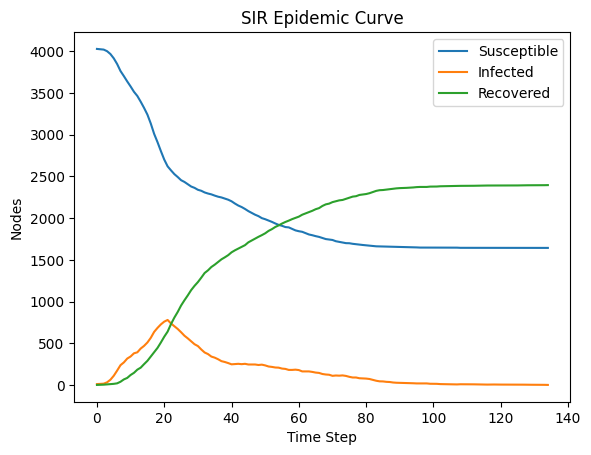


Peak Infection: 779
Peak Time Step: 21
Final Epidemic Size: 2396


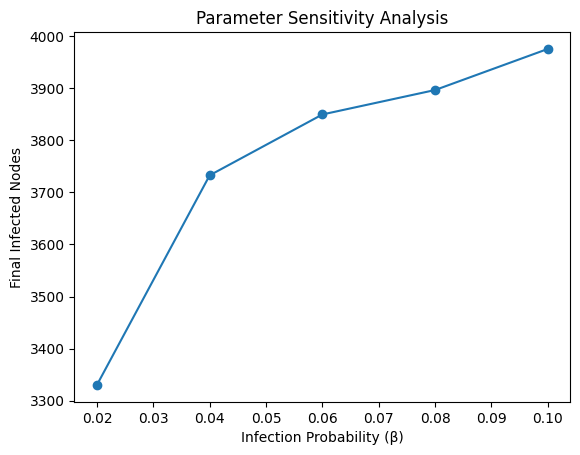

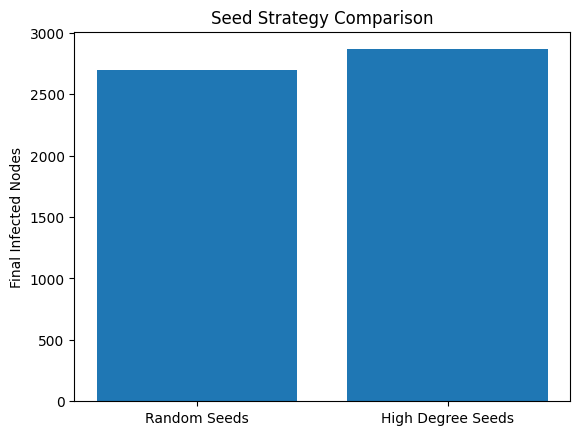

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np




def load_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_states(G, initial_infected):

    state = {node: "S" for node in G.nodes()}

    for node in initial_infected:
        state[node] = "I"

    return state




def SIR_model(G, state, beta=0.01, gamma=0.1):

    S_curve = []
    I_curve = []
    R_curve = []

    while True:

        new_state = state.copy()

        for node in G.nodes():

            if state[node] == "I":

                for neighbor in G.neighbors(node):

                    if state[neighbor] == "S":

                        if random.random() < beta:
                            new_state[neighbor] = "I"

                if random.random() < gamma:
                    new_state[node] = "R"

        state = new_state

        S = list(state.values()).count("S")
        I = list(state.values()).count("I")
        R = list(state.values()).count("R")

        S_curve.append(S)
        I_curve.append(I)
        R_curve.append(R)

        if I == 0:
            break

    return S_curve, I_curve, R_curve




def plot_epidemic_curve(S, I, R):

    plt.figure()

    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected")
    plt.plot(R, label="Recovered")

    plt.xlabel("Time Step")
    plt.ylabel("Nodes")

    plt.title("SIR Epidemic Curve")

    plt.legend()
    plt.show()



def peak_analysis(I_curve):

    peak_value = max(I_curve)
    peak_time = I_curve.index(peak_value)

    print("\nPeak Infection:", peak_value)
    print("Peak Time Step:", peak_time)




def final_epidemic_size(R_curve):

    final_size = R_curve[-1]

    print("Final Epidemic Size:", final_size)




def beta_sensitivity(G):

    betas = [0.02,0.04,0.06,0.08,0.1]

    results = []

    for beta in betas:

        seeds = random.sample(list(G.nodes()),10)

        state = initialize_states(G,seeds)

        S,I,R = SIR_model(G,state,beta=beta)

        results.append(R[-1])

    plt.figure()

    plt.plot(betas,results,marker='o')

    plt.xlabel("Infection Probability (β)")
    plt.ylabel("Final Infected Nodes")

    plt.title("Parameter Sensitivity Analysis")

    plt.show()




def seed_strategy(G):

    nodes = list(G.nodes())

    random_seeds = random.sample(nodes,10)

    degree_nodes = sorted(G.degree,key=lambda x:x[1],reverse=True)

    high_degree = [n for n,_ in degree_nodes[:10]]

    spreads = []

    for seeds in [random_seeds,high_degree]:

        state = initialize_states(G,seeds)

        S,I,R = SIR_model(G,state)

        spreads.append(R[-1])

    plt.figure()

    plt.bar(["Random Seeds","High Degree Seeds"],spreads)

    plt.ylabel("Final Infected Nodes")

    plt.title("Seed Strategy Comparison")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_graph(path)

    seeds = random.sample(list(G.nodes()),10)

    state = initialize_states(G,seeds)

    S,I,R = SIR_model(G,state)

    plot_epidemic_curve(S,I,R)

    peak_analysis(I)

    final_epidemic_size(R)

    beta_sensitivity(G)

    seed_strategy(G)

Nodes: 7115
Edges: 100762


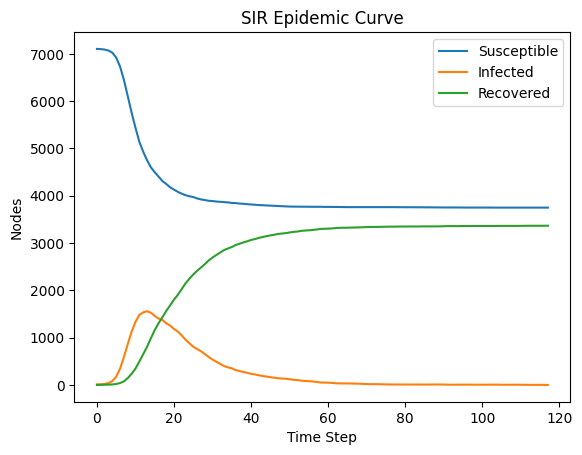


Peak Infection: 1558
Peak Time Step: 13
Final Epidemic Size: 3366


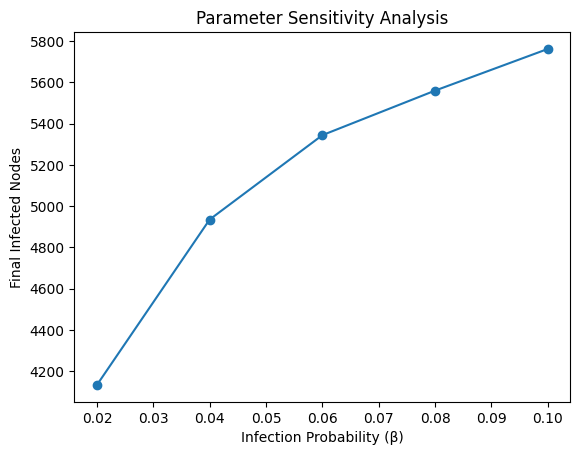

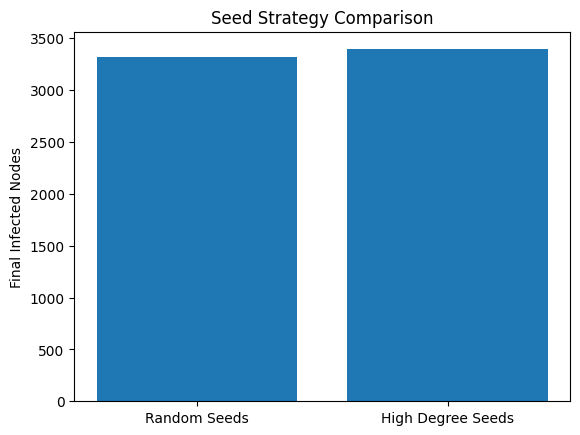

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np





def load_graph(path):

    G = nx.read_edgelist(
    path,
    nodetype=int,
    comments="#",
    create_using=nx.DiGraph()
)

    G = G.to_undirected()

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G



def initialize_states(G, initial_infected):

    state = {node: "S" for node in G.nodes()}

    for node in initial_infected:
        state[node] = "I"

    return state




def SIR_model(G, state, beta=0.01, gamma=0.1):

    S_curve = []
    I_curve = []
    R_curve = []

    while True:

        new_state = state.copy()

        for node in G.nodes():

            if state[node] == "I":

                for neighbor in G.neighbors(node):

                    if state[neighbor] == "S":

                        if random.random() < beta:
                            new_state[neighbor] = "I"

                if random.random() < gamma:
                    new_state[node] = "R"

        state = new_state

        S = list(state.values()).count("S")
        I = list(state.values()).count("I")
        R = list(state.values()).count("R")

        S_curve.append(S)
        I_curve.append(I)
        R_curve.append(R)

        if I == 0:
            break

    return S_curve, I_curve, R_curve




def plot_epidemic_curve(S, I, R):

    plt.figure()

    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected")
    plt.plot(R, label="Recovered")

    plt.xlabel("Time Step")
    plt.ylabel("Nodes")

    plt.title("SIR Epidemic Curve")

    plt.legend()
    plt.show()



def peak_analysis(I_curve):

    peak_value = max(I_curve)
    peak_time = I_curve.index(peak_value)

    print("\nPeak Infection:", peak_value)
    print("Peak Time Step:", peak_time)



def final_epidemic_size(R_curve):

    final_size = R_curve[-1]

    print("Final Epidemic Size:", final_size)




def beta_sensitivity(G):

    betas = [0.02,0.04,0.06,0.08,0.1]

    results = []

    for beta in betas:

        seeds = random.sample(list(G.nodes()),10)

        state = initialize_states(G,seeds)

        S,I,R = SIR_model(G,state,beta=beta)

        results.append(R[-1])

    plt.figure()

    plt.plot(betas,results,marker='o')

    plt.xlabel("Infection Probability (β)")
    plt.ylabel("Final Infected Nodes")

    plt.title("Parameter Sensitivity Analysis")

    plt.show()



def seed_strategy(G):

    nodes = list(G.nodes())

    random_seeds = random.sample(nodes,10)

    degree_nodes = sorted(G.degree,key=lambda x:x[1],reverse=True)

    high_degree = [n for n,_ in degree_nodes[:10]]

    spreads = []

    for seeds in [random_seeds,high_degree]:

        state = initialize_states(G,seeds)

        S,I,R = SIR_model(G,state)

        spreads.append(R[-1])

    plt.figure()

    plt.bar(["Random Seeds","High Degree Seeds"],spreads)

    plt.ylabel("Final Infected Nodes")

    plt.title("Seed Strategy Comparison")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/Wiki-Vote.txt"

    G = load_graph(path)

    seeds = random.sample(list(G.nodes()),10)

    state = initialize_states(G,seeds)

    S,I,R = SIR_model(G,state)

    plot_epidemic_curve(S,I,R)

    peak_analysis(I)

    final_epidemic_size(R)

    beta_sensitivity(G)

    seed_strategy(G)

Nodes: 4039
Edges: 88234


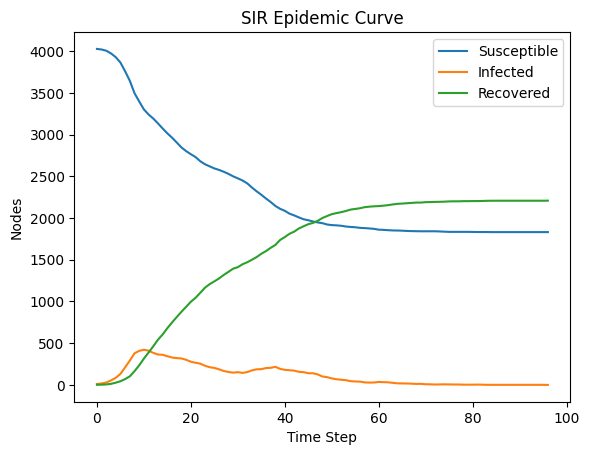


Peak Infection: 422
Peak Time Step: 10
Final Epidemic Size: 2208


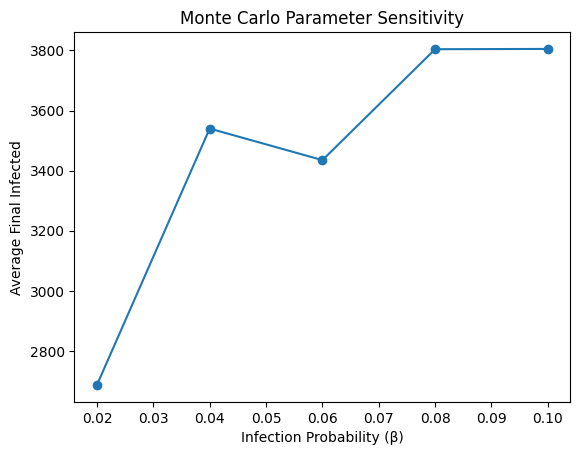

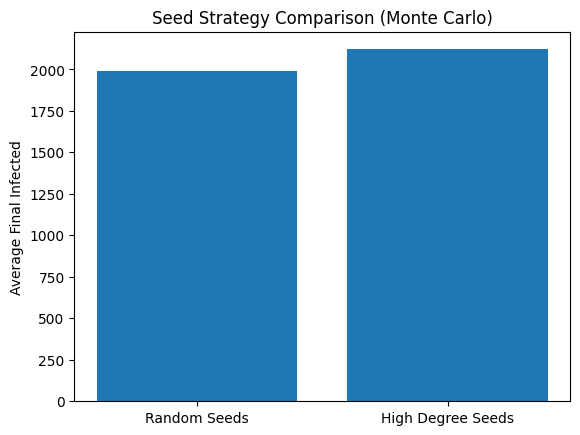

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np




def load_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_states(G, initial_infected):

    state = {node: "S" for node in G.nodes()}

    for node in initial_infected:
        state[node] = "I"

    return state




def SIR_model(G, state, beta=0.01, gamma=0.2):

    S_curve, I_curve, R_curve = [], [], []

    while True:

        new_state = state.copy()

        for node in G.nodes():

            if state[node] == "I":

                for neighbor in G.neighbors(node):

                    if state[neighbor] == "S":

                        if random.random() < beta:
                            new_state[neighbor] = "I"

                if random.random() < gamma:
                    new_state[node] = "R"

        state = new_state

        S = list(state.values()).count("S")
        I = list(state.values()).count("I")
        R = list(state.values()).count("R")

        S_curve.append(S)
        I_curve.append(I)
        R_curve.append(R)

        if I == 0:
            break

    return S_curve, I_curve, R_curve



def monte_carlo_simulation(G, seeds, runs=1, beta=0.01, gamma=0.2):

    spreads = []

    for _ in range(runs):

        state = initialize_states(G, seeds)

        S, I, R = SIR_model(G, state, beta, gamma)

        spreads.append(R[-1])

    return np.mean(spreads)



def plot_epidemic_curve(S, I, R):

    plt.figure()

    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected")
    plt.plot(R, label="Recovered")

    plt.xlabel("Time Step")
    plt.ylabel("Nodes")

    plt.title("SIR Epidemic Curve")

    plt.legend()
    plt.show()



def peak_analysis(I_curve):

    peak_value = max(I_curve)
    peak_time = I_curve.index(peak_value)

    print("\nPeak Infection:", peak_value)
    print("Peak Time Step:", peak_time)



def final_epidemic_size(R_curve):

    final_size = R_curve[-1]

    print("Final Epidemic Size:", final_size)



def beta_sensitivity(G):

    betas = [0.02,0.04,0.06,0.08,0.1]

    results = []

    for beta in betas:

        seeds = random.sample(list(G.nodes()),10)

        spread = monte_carlo_simulation(G,seeds,runs=1,beta=beta)

        results.append(spread)

    plt.figure()

    plt.plot(betas,results,marker='o')

    plt.xlabel("Infection Probability (β)")
    plt.ylabel("Average Final Infected")

    plt.title("Monte Carlo Parameter Sensitivity")

    plt.show()



def seed_strategy(G):

    nodes = list(G.nodes())

    random_seeds = random.sample(nodes,10)

    degree_nodes = sorted(G.degree,key=lambda x:x[1],reverse=True)

    high_degree = [n for n,_ in degree_nodes[:10]]

    spreads = []

    for seeds in [random_seeds,high_degree]:

        spread = monte_carlo_simulation(G,seeds,runs=1)

        spreads.append(spread)

    plt.figure()

    plt.bar(["Random Seeds","High Degree Seeds"],spreads)

    plt.ylabel("Average Final Infected")

    plt.title("Seed Strategy Comparison (Monte Carlo)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_graph(path)

    seeds = random.sample(list(G.nodes()),10)

    state = initialize_states(G,seeds)

    S,I,R = SIR_model(G,state)

    plot_epidemic_curve(S,I,R)

    peak_analysis(I)

    final_epidemic_size(R)

    beta_sensitivity(G)

    seed_strategy(G)

**SIS model**

Nodes: 4039
Edges: 88234


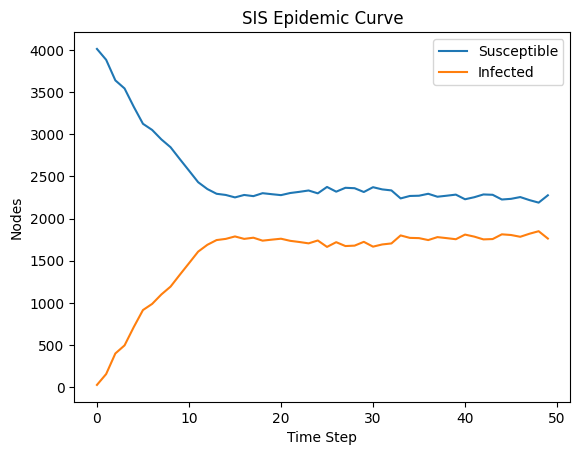


Peak Infection: 1850
Peak Time Step: 48


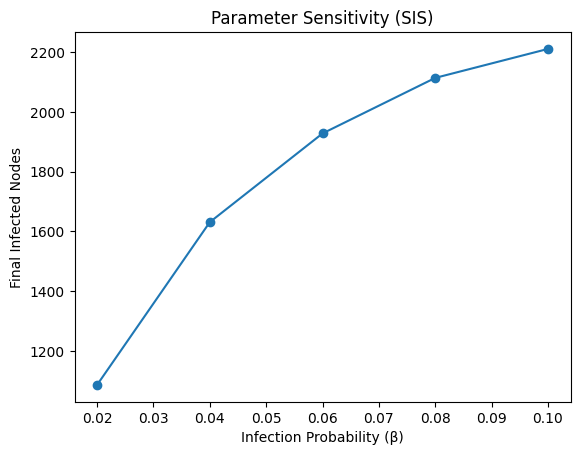

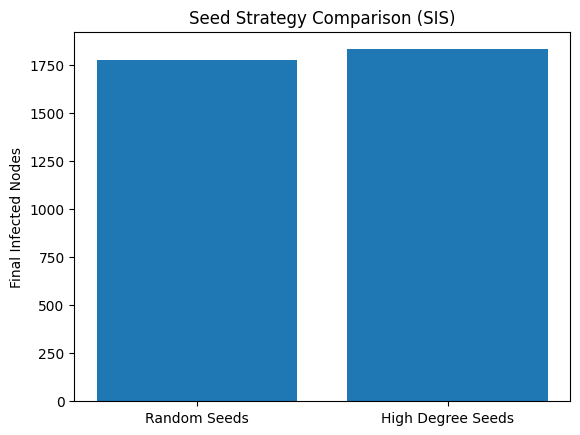

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt




def load_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G



def initialize_states(G, initial_infected):

    state = {node: "S" for node in G.nodes()}

    for node in initial_infected:
        state[node] = "I"

    return state




def SIS_model(G, state, beta=0.05, gamma=0.5, steps=50):

    S_curve = []
    I_curve = []

    for _ in range(steps):

        new_state = state.copy()

        for node in G.nodes():

            if state[node] == "I":

                # Infect neighbors
                for neighbor in G.neighbors(node):

                    if state[neighbor] == "S":

                        if random.random() < beta:
                            new_state[neighbor] = "I"

                # Recovery (back to susceptible)
                if random.random() < gamma:
                    new_state[node] = "S"

        state = new_state

        S_count = list(state.values()).count("S")
        I_count = list(state.values()).count("I")

        S_curve.append(S_count)
        I_curve.append(I_count)

    return S_curve, I_curve




def plot_epidemic_curve(S, I):

    plt.figure()

    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected")

    plt.xlabel("Time Step")
    plt.ylabel("Nodes")

    plt.title("SIS Epidemic Curve")

    plt.legend()

    plt.show()




def peak_analysis(I_curve):

    peak_value = max(I_curve)
    peak_time = I_curve.index(peak_value)

    print("\nPeak Infection:", peak_value)
    print("Peak Time Step:", peak_time)




def beta_sensitivity(G):

    betas = [0.02,0.04,0.06,0.08,0.1]

    results = []

    for beta in betas:

        seeds = random.sample(list(G.nodes()),10)

        state = initialize_states(G,seeds)

        S,I = SIS_model(G,state,beta=beta)

        results.append(I[-1])

    plt.figure()

    plt.plot(betas,results,marker='o')

    plt.xlabel("Infection Probability (β)")
    plt.ylabel("Final Infected Nodes")

    plt.title("Parameter Sensitivity (SIS)")

    plt.show()




def seed_strategy(G):

    nodes = list(G.nodes())

    random_seeds = random.sample(nodes,10)

    degree_nodes = sorted(G.degree,key=lambda x:x[1],reverse=True)

    high_degree = [n for n,_ in degree_nodes[:10]]

    spreads = []

    for seeds in [random_seeds,high_degree]:

        state = initialize_states(G,seeds)

        S,I = SIS_model(G,state)

        spreads.append(I[-1])

    plt.figure()

    plt.bar(["Random Seeds","High Degree Seeds"],spreads)

    plt.ylabel("Final Infected Nodes")

    plt.title("Seed Strategy Comparison (SIS)")

    plt.show()



if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_graph(path)

    seeds = random.sample(list(G.nodes()),10)

    state = initialize_states(G,seeds)

    S,I = SIS_model(G,state)

    plot_epidemic_curve(S,I)

    peak_analysis(I)

    beta_sensitivity(G)

    seed_strategy(G)

**SIRS Model**

Nodes: 4039
Edges: 88234


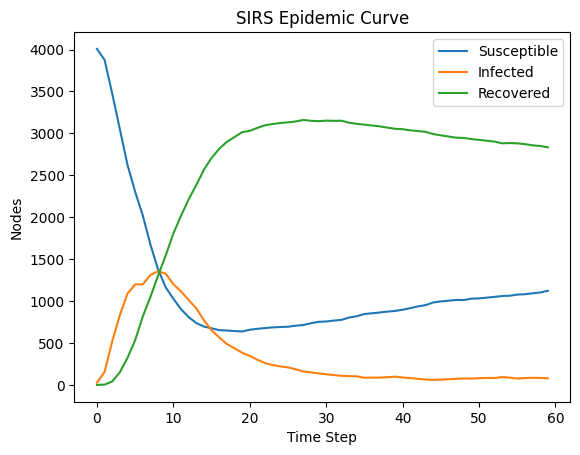


Peak Infection: 1356
Peak Time Step: 8


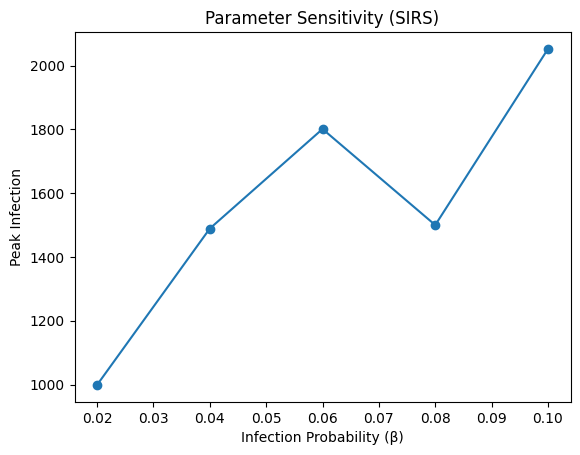

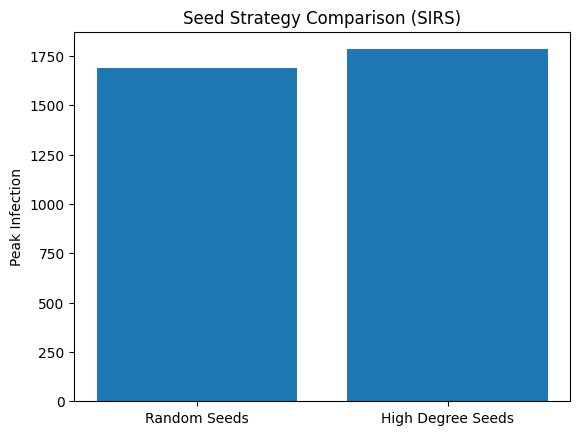

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt




def load_graph(path):

    G = nx.read_edgelist(path, nodetype=int)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    return G




def initialize_states(G, infected_nodes):

    state = {node: "S" for node in G.nodes()}

    for node in infected_nodes:
        state[node] = "I"

    return state




def SIRS_model(G, state, beta=0.05, gamma=0.2, delta=0.01, steps=60):

    S_curve = []
    I_curve = []
    R_curve = []

    for _ in range(steps):

        new_state = state.copy()

        for node in G.nodes():

            # Infection
            if state[node] == "I":

                for neighbor in G.neighbors(node):

                    if state[neighbor] == "S":

                        if random.random() < beta:
                            new_state[neighbor] = "I"

                # Recovery
                if random.random() < gamma:
                    new_state[node] = "R"


            # Immunity loss
            elif state[node] == "R":

                if random.random() < delta:
                    new_state[node] = "S"

        state = new_state

        S_count = list(state.values()).count("S")
        I_count = list(state.values()).count("I")
        R_count = list(state.values()).count("R")

        S_curve.append(S_count)
        I_curve.append(I_count)
        R_curve.append(R_count)

    return S_curve, I_curve, R_curve




def plot_epidemic_curve(S, I, R):

    plt.figure()

    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected")
    plt.plot(R, label="Recovered")

    plt.xlabel("Time Step")
    plt.ylabel("Nodes")

    plt.title("SIRS Epidemic Curve")

    plt.legend()

    plt.show()




def peak_analysis(I_curve):

    peak_value = max(I_curve)
    peak_time = I_curve.index(peak_value)

    print("\nPeak Infection:", peak_value)
    print("Peak Time Step:", peak_time)




def beta_sensitivity(G):

    betas = [0.02,0.04,0.06,0.08,0.1]

    results = []

    for beta in betas:

        seeds = random.sample(list(G.nodes()),10)

        state = initialize_states(G,seeds)

        S,I,R = SIRS_model(G,state,beta=beta)

        results.append(max(I))

    plt.figure()

    plt.plot(betas,results,marker='o')

    plt.xlabel("Infection Probability (β)")
    plt.ylabel("Peak Infection")

    plt.title("Parameter Sensitivity (SIRS)")

    plt.show()



def seed_strategy(G):

    nodes = list(G.nodes())

    random_seeds = random.sample(nodes,10)

    degree_nodes = sorted(G.degree,key=lambda x:x[1],reverse=True)

    high_degree = [n for n,_ in degree_nodes[:10]]

    spreads = []

    for seeds in [random_seeds,high_degree]:

        state = initialize_states(G,seeds)

        S,I,R = SIRS_model(G,state)

        spreads.append(max(I))

    plt.figure()

    plt.bar(["Random Seeds","High Degree Seeds"],spreads)

    plt.ylabel("Peak Infection")

    plt.title("Seed Strategy Comparison (SIRS)")

    plt.show()




if __name__ == "__main__":

    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"

    G = load_graph(path)

    seeds = random.sample(list(G.nodes()),10)

    state = initialize_states(G,seeds)

    S,I,R = SIRS_model(G,state)

    plot_epidemic_curve(S,I,R)

    peak_analysis(I)

    beta_sensitivity(G)

    seed_strategy(G)

# **4. Competitive Model**

**Distance Based Model**

Nodes: 4039
Edges: 88234
Seeds A: [2825, 2962, 150, 1380, 518, 3931, 2436, 3379, 2014, 3361]
Seeds B: [2466, 2088, 1608, 1145, 744, 2711, 1283, 148, 424, 3854]
Adopted Campaign A: 311
Adopted Campaign B: 530
Neutral Nodes: 3198


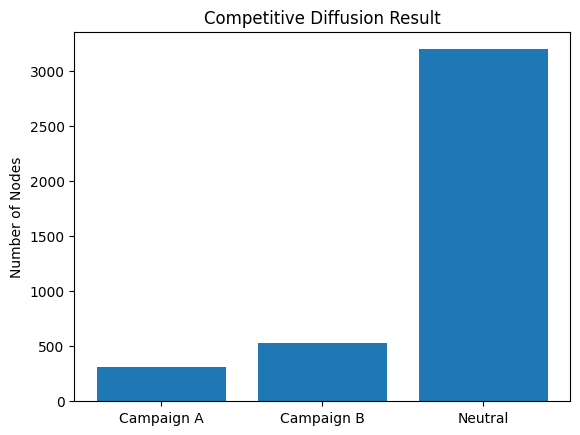

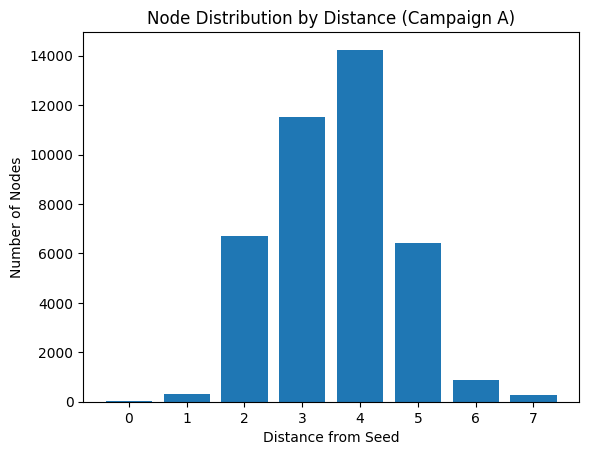

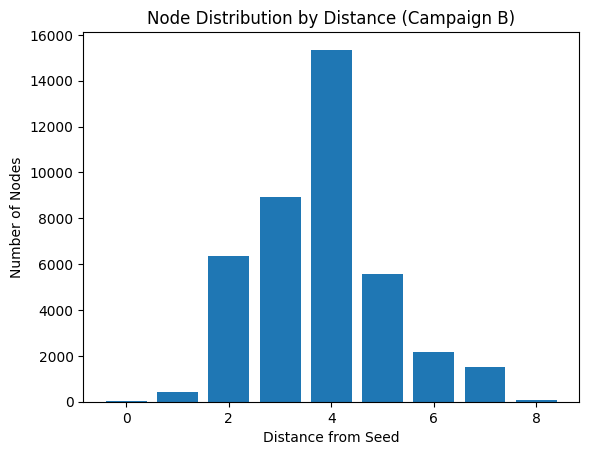

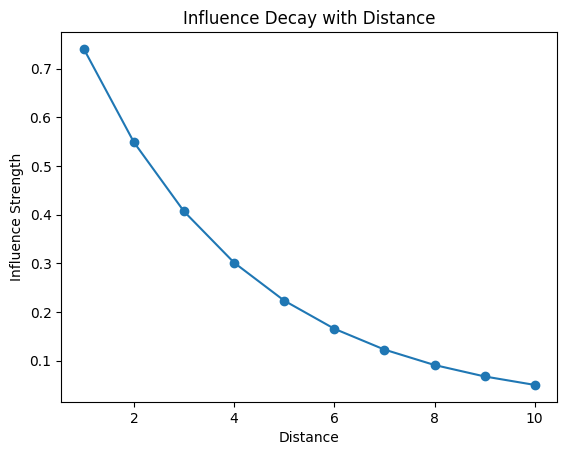

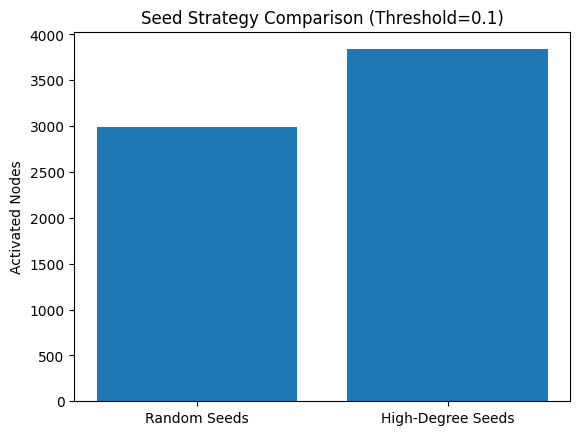

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import math

def load_graph(path):
    G = nx.read_edgelist(path, nodetype=int)
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G


def competitive_distance_diffusion(G, seeds_A, seeds_B, alpha=0.3, threshold=0.1):
    influence_A = {node:0 for node in G.nodes()}
    influence_B = {node:0 for node in G.nodes()}

    # Influence from campaign A
    for seed in seeds_A:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, dist in lengths.items():
            influence_A[node] = max(influence_A[node], math.exp(-alpha*dist))

    # Influence from campaign B
    for seed in seeds_B:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, dist in lengths.items():
            influence_B[node] = max(influence_B[node], math.exp(-alpha*dist))

    adopted_A, adopted_B, neutral = [], [], []
    for node in G.nodes():
        if influence_A[node] > influence_B[node] and influence_A[node] >= threshold:
            adopted_A.append(node)
        elif influence_B[node] > influence_A[node] and influence_B[node] >= threshold:
            adopted_B.append(node)
        else:
            neutral.append(node)

    return adopted_A, adopted_B, neutral, influence_A, influence_B


def distance_distribution(G, seeds, label):
    dist_counts = {}
    for seed in seeds:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, d in lengths.items():
            dist_counts[d] = dist_counts.get(d,0)+1
    x = sorted(dist_counts.keys())
    y = [dist_counts[i] for i in x]
    plt.figure()
    plt.bar(x, y)
    plt.xlabel("Distance from Seed")
    plt.ylabel("Number of Nodes")
    plt.title(f"Node Distribution by Distance ({label})")
    plt.show()


def influence_decay_plot(alpha=0.5, max_dist=10):
    distances = range(1, max_dist+1)
    influence = [math.exp(-alpha*d) for d in distances]
    plt.figure()
    plt.plot(distances, influence, marker='o')
    plt.xlabel("Distance")
    plt.ylabel("Influence Strength")
    plt.title("Influence Decay with Distance")
    plt.show()


def seed_strategy_comparison(G, alpha=1, threshold=0.9):
    nodes = list(G.nodes())
    random_seeds = random.sample(nodes, 10)
    degree_nodes = sorted(G.degree, key=lambda x:x[1], reverse=True)
    high_degree_seeds = [n for n,_ in degree_nodes[:10]]
    spreads = []
    for seeds in [random_seeds, high_degree_seeds]:
        adopted, _, _, _, _ = competitive_distance_diffusion(G, seeds, [], alpha, threshold)
        spreads.append(len(adopted))
    plt.figure()
    plt.bar(["Random Seeds","High-Degree Seeds"], spreads)
    plt.ylabel("Activated Nodes")
    plt.title(f"Seed Strategy Comparison (Threshold={threshold})")
    plt.show()


def competitive_analysis(G, alpha=0.3, threshold=0.1):
    nodes = list(G.nodes())
    seeds_A = random.sample(nodes,10)
    seeds_B = random.sample(nodes,10)
    print("Seeds A:", seeds_A)
    print("Seeds B:", seeds_B)

    A, B, N, influence_A, influence_B = competitive_distance_diffusion(G,seeds_A,seeds_B, alpha, threshold)

    print("Adopted Campaign A:", len(A))
    print("Adopted Campaign B:", len(B))
    print("Neutral Nodes:", len(N))


    plt.figure()
    plt.bar(["Campaign A","Campaign B","Neutral"], [len(A),len(B),len(N)])
    plt.ylabel("Number of Nodes")
    plt.title("Competitive Diffusion Result")
    plt.show()


    distance_distribution(G,seeds_A,"Campaign A")
    distance_distribution(G,seeds_B,"Campaign B")


    influence_decay_plot(alpha)

if __name__ == "__main__":
    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"
    G = load_graph(path)
    competitive_analysis(G, alpha=0.3, threshold=0.1)
    seed_strategy_comparison(G, alpha=1, threshold=0.1)

Nodes: 7115
Edges: 100762
Seeds A: [1281, 2993, 4763, 418, 7428, 2015, 4633, 596, 8173, 2255]
Seeds B: [7756, 121, 3953, 1155, 54, 1753, 3514, 3594, 6454, 7175]
Adopted Campaign A: 1874
Adopted Campaign B: 703
Neutral Nodes: 4538


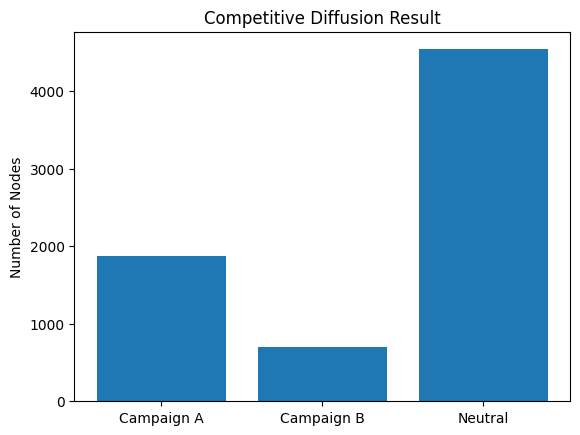

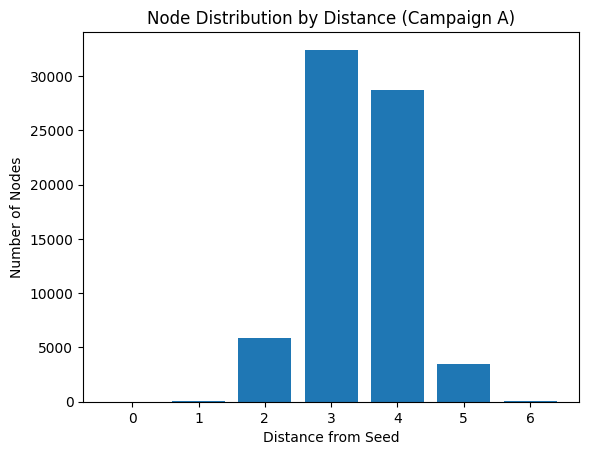

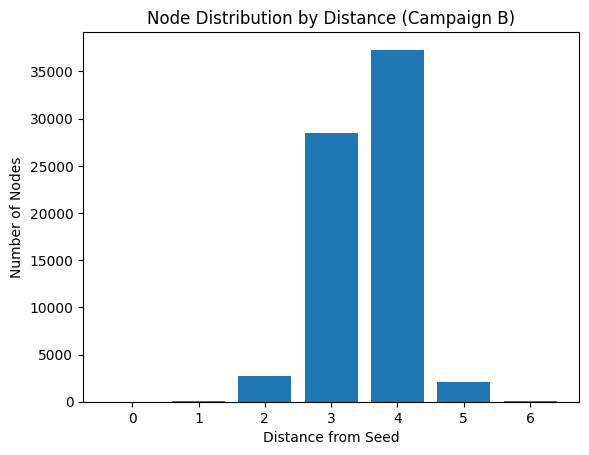

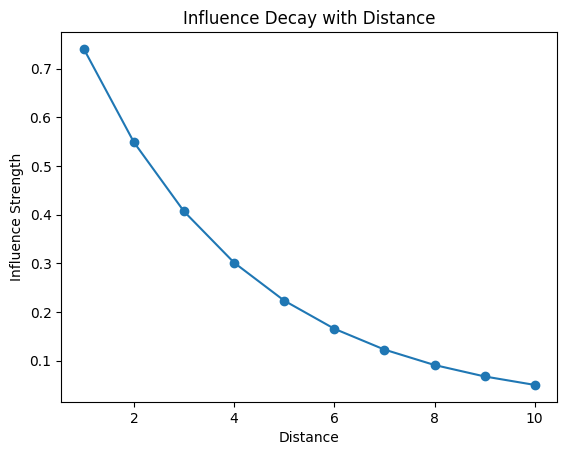

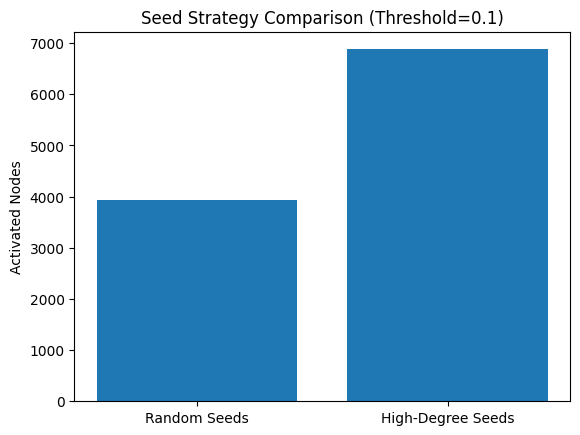

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import math


def load_graph(path):
    G = nx.read_edgelist(
    path,
    nodetype=int,
    comments="#",
    create_using=nx.DiGraph()
)

    G = G.to_undirected()
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G


def competitive_distance_diffusion(G, seeds_A, seeds_B, alpha=0.3, threshold=0.1):
    influence_A = {node:0 for node in G.nodes()}
    influence_B = {node:0 for node in G.nodes()}

    # Influence from campaign A
    for seed in seeds_A:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, dist in lengths.items():
            influence_A[node] = max(influence_A[node], math.exp(-alpha*dist))

    # Influence from campaign B
    for seed in seeds_B:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, dist in lengths.items():
            influence_B[node] = max(influence_B[node], math.exp(-alpha*dist))

    adopted_A, adopted_B, neutral = [], [], []
    for node in G.nodes():
        if influence_A[node] > influence_B[node] and influence_A[node] >= threshold:
            adopted_A.append(node)
        elif influence_B[node] > influence_A[node] and influence_B[node] >= threshold:
            adopted_B.append(node)
        else:
            neutral.append(node)

    return adopted_A, adopted_B, neutral, influence_A, influence_B


def distance_distribution(G, seeds, label):
    dist_counts = {}
    for seed in seeds:
        lengths = nx.single_source_shortest_path_length(G, seed)
        for node, d in lengths.items():
            dist_counts[d] = dist_counts.get(d,0)+1
    x = sorted(dist_counts.keys())
    y = [dist_counts[i] for i in x]
    plt.figure()
    plt.bar(x, y)
    plt.xlabel("Distance from Seed")
    plt.ylabel("Number of Nodes")
    plt.title(f"Node Distribution by Distance ({label})")
    plt.show()


def influence_decay_plot(alpha=0.5, max_dist=10):
    distances = range(1, max_dist+1)
    influence = [math.exp(-alpha*d) for d in distances]
    plt.figure()
    plt.plot(distances, influence, marker='o')
    plt.xlabel("Distance")
    plt.ylabel("Influence Strength")
    plt.title("Influence Decay with Distance")
    plt.show()


def seed_strategy_comparison(G, alpha=1, threshold=0.9):
    nodes = list(G.nodes())
    random_seeds = random.sample(nodes, 10)
    degree_nodes = sorted(G.degree, key=lambda x:x[1], reverse=True)
    high_degree_seeds = [n for n,_ in degree_nodes[:10]]
    spreads = []
    for seeds in [random_seeds, high_degree_seeds]:
        adopted, _, _, _, _ = competitive_distance_diffusion(G, seeds, [], alpha, threshold)
        spreads.append(len(adopted))
    plt.figure()
    plt.bar(["Random Seeds","High-Degree Seeds"], spreads)
    plt.ylabel("Activated Nodes")
    plt.title(f"Seed Strategy Comparison (Threshold={threshold})")
    plt.show()


def competitive_analysis(G, alpha=0.3, threshold=0.1):
    nodes = list(G.nodes())
    seeds_A = random.sample(nodes,10)
    seeds_B = random.sample(nodes,10)
    print("Seeds A:", seeds_A)
    print("Seeds B:", seeds_B)

    A, B, N, influence_A, influence_B = competitive_distance_diffusion(G,seeds_A,seeds_B, alpha, threshold)

    print("Adopted Campaign A:", len(A))
    print("Adopted Campaign B:", len(B))
    print("Neutral Nodes:", len(N))

    # Bar chart of adoption
    plt.figure()
    plt.bar(["Campaign A","Campaign B","Neutral"], [len(A),len(B),len(N)])
    plt.ylabel("Number of Nodes")
    plt.title("Competitive Diffusion Result")
    plt.show()

    # Distance distributions
    distance_distribution(G,seeds_A,"Campaign A")
    distance_distribution(G,seeds_B,"Campaign B")

    # Influence decay
    influence_decay_plot(alpha)

    # Seed strategy comparison



if __name__ == "__main__":
    path = "/content/drive/MyDrive/Explo Datasets/Wiki-Vote.txt"
    G = load_graph(path)
    competitive_analysis(G, alpha=0.3, threshold=0.1)
    seed_strategy_comparison(G, alpha=1, threshold=0.1)

**Wave Propagation Model**

Nodes: 4039
Edges: 88234
Total Activated Nodes Campaign A: 2248
Total Activated Nodes Campaign B: 1791
Neutral Nodes: 0


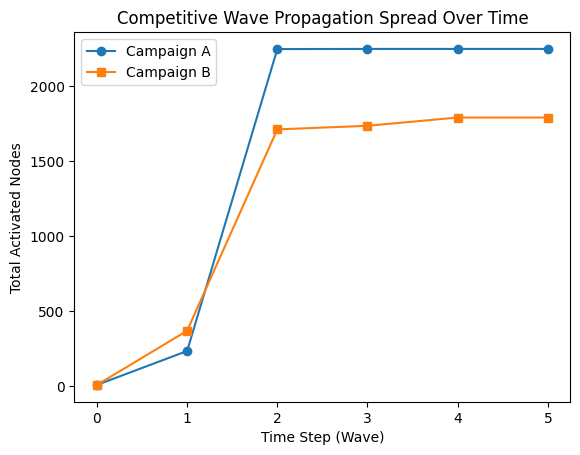

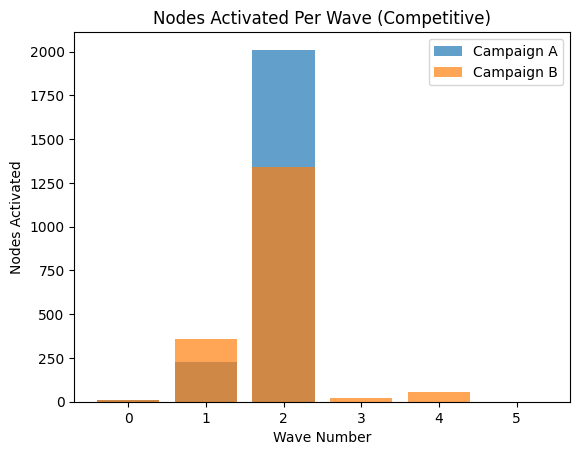

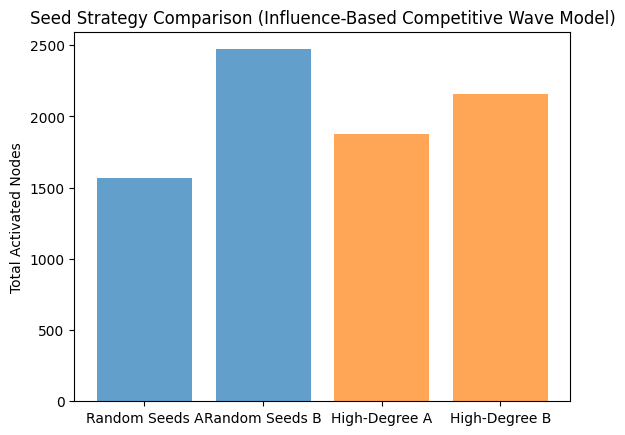

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import math


def load_graph(path):
    G = nx.read_edgelist(path, nodetype=int)
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    return G


def competitive_wave_propagation_influence(G, seeds_A, seeds_B, decay=0.7):
    active_A = set(seeds_A)
    active_B = set(seeds_B)
    wave_nodes_A = set(seeds_A)
    wave_nodes_B = set(seeds_B)

    spread_over_time_A = [len(active_A)]
    spread_over_time_B = [len(active_B)]
    wave_sizes_A = [len(seeds_A)]
    wave_sizes_B = [len(seeds_B)]

    # Keep track of distance from each campaign seed
    distance_A = {node:0 for node in seeds_A}
    distance_B = {node:0 for node in seeds_B}

    wave = 0
    while wave_nodes_A or wave_nodes_B:
        new_wave_A = set()
        new_wave_B = set()
        influence = decay ** (wave + 1)


        potential_influence = {}

        # Campaign A
        for node in wave_nodes_A:
            for neighbor in G.neighbors(node):
                if neighbor not in active_A and neighbor not in active_B:
                    potential_influence[neighbor] = potential_influence.get(neighbor, {})
                    potential_influence[neighbor]['A'] = decay ** (distance_A[node] + 1)

        # Campaign B
        for node in wave_nodes_B:
            for neighbor in G.neighbors(node):
                if neighbor not in active_A and neighbor not in active_B:
                    potential_influence[neighbor] = potential_influence.get(neighbor, {})
                    potential_influence[neighbor]['B'] = decay ** (distance_B[node] + 1)


        for neighbor, inf_dict in potential_influence.items():
            inf_A = inf_dict.get('A',0)
            inf_B = inf_dict.get('B',0)
            if inf_A > inf_B:
                new_wave_A.add(neighbor)
                distance_A[neighbor] = wave + 1
            elif inf_B > inf_A:
                new_wave_B.add(neighbor)
                distance_B[neighbor] = wave + 1
            else:
                # Tie: assign randomly
                if random.random() < 0.5:
                    new_wave_A.add(neighbor)
                    distance_A[neighbor] = wave + 1
                else:
                    new_wave_B.add(neighbor)
                    distance_B[neighbor] = wave + 1


        active_A.update(new_wave_A)
        active_B.update(new_wave_B)
        wave_nodes_A = new_wave_A
        wave_nodes_B = new_wave_B

        wave += 1
        spread_over_time_A.append(len(active_A))
        spread_over_time_B.append(len(active_B))
        wave_sizes_A.append(len(new_wave_A))
        wave_sizes_B.append(len(new_wave_B))

    neutral = set(G.nodes()) - active_A - active_B
    return active_A, active_B, neutral, spread_over_time_A, spread_over_time_B, wave_sizes_A, wave_sizes_B


def plot_spread(spread_A, spread_B):
    plt.figure()
    plt.plot(range(len(spread_A)), spread_A, marker='o', label="Campaign A")
    plt.plot(range(len(spread_B)), spread_B, marker='s', label="Campaign B")
    plt.xlabel("Time Step (Wave)")
    plt.ylabel("Total Activated Nodes")
    plt.title("Competitive Wave Propagation Spread Over Time")
    plt.legend()
    plt.show()


def plot_wave_sizes(wave_sizes_A, wave_sizes_B):
    plt.figure()
    plt.bar(range(len(wave_sizes_A)), wave_sizes_A, alpha=0.7, label="Campaign A")
    plt.bar(range(len(wave_sizes_B)), wave_sizes_B, alpha=0.7, label="Campaign B")
    plt.xlabel("Wave Number")
    plt.ylabel("Nodes Activated")
    plt.title("Nodes Activated Per Wave (Competitive)")
    plt.legend()
    plt.show()


def seed_strategy(G):
    nodes = list(G.nodes())
    random_seeds_A = random.sample(nodes, 10)
    random_seeds_B = random.sample(nodes, 10)

    degree_nodes = sorted(G.degree, key=lambda x:x[1], reverse=True)
    high_degree_nodes = [n for n,d in degree_nodes[:20]]
    high_degree_A = [high_degree_nodes[i] for i in range(0, len(high_degree_nodes), 2)]
    high_degree_B = [high_degree_nodes[i] for i in range(1, len(high_degree_nodes), 2)]  # avoid overlap

    spreads = []
    for seeds_A, seeds_B in [(random_seeds_A, random_seeds_B), (high_degree_A, high_degree_B)]:
        active_A, active_B, neutral, spread_A, spread_B, wave_sizes_A, wave_sizes_B = competitive_wave_propagation_influence(G, seeds_A, seeds_B)
        spreads.append((len(active_A), len(active_B)))

    plt.figure()
    plt.bar(["Random Seeds A","Random Seeds B"], [spreads[0][0], spreads[0][1]], alpha=0.7)
    plt.bar(["High-Degree A","High-Degree B"], [spreads[1][0], spreads[1][1]], alpha=0.7)
    plt.ylabel("Total Activated Nodes")
    plt.title("Seed Strategy Comparison (Influence-Based Competitive Wave Model)")
    plt.show()


if __name__ == "__main__":
    path = "/content/drive/MyDrive/Explo Datasets/facebook_combined.txt"
    G = load_graph(path)

    seeds_A = random.sample(list(G.nodes()), 10)
    seeds_B = random.sample(list(G.nodes()), 10)

    active_A, active_B, neutral, spread_A, spread_B, wave_sizes_A, wave_sizes_B = competitive_wave_propagation_influence(G, seeds_A, seeds_B)

    print("Total Activated Nodes Campaign A:", len(active_A))
    print("Total Activated Nodes Campaign B:", len(active_B))
    print("Neutral Nodes:", len(neutral))

    plot_spread(spread_A, spread_B)
    plot_wave_sizes(wave_sizes_A, wave_sizes_B)
    seed_strategy(G)

**Weight Proportional Threshold Model**

Nodes: 4039
Edges: 88234
Total Activated Nodes Campaign A: 19
Total Activated Nodes Campaign B: 49
Neutral Nodes: 3971


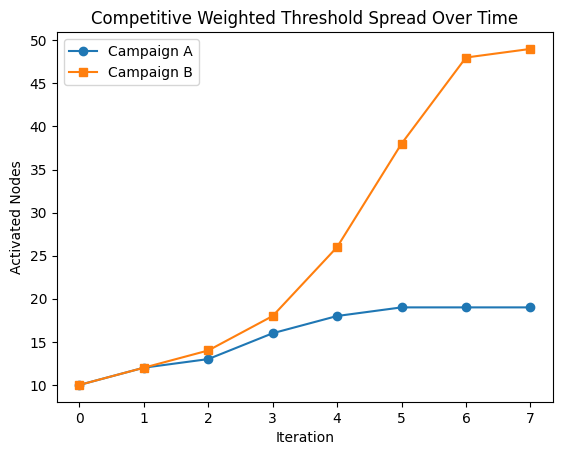

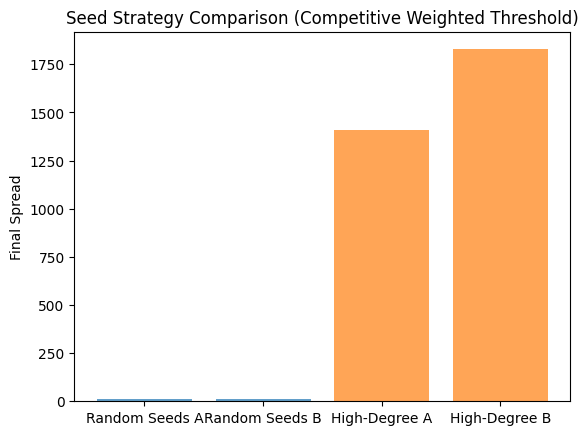

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt


G = nx.read_edgelist("/content/drive/MyDrive/Explo Datasets/facebook_combined.txt", nodetype=int)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


for u, v in G.edges():
    G[u][v]['weight'] = random.uniform(0.1, 1)


def competitive_weighted_threshold(G, seeds_A, seeds_B, threshold_range=(0.1,0.4)):
    active_A = set(seeds_A)
    active_B = set(seeds_B)

    thresholds = {node: random.uniform(*threshold_range) for node in G.nodes()}
    spread_over_time_A = [len(active_A)]
    spread_over_time_B = [len(active_B)]

    changed = True
    while changed:
        changed = False
        new_active_A = set()
        new_active_B = set()

        for node in G.nodes():
            if node in active_A or node in active_B:
                continue

            influence_A = 0
            influence_B = 0
            total_weight = 0

            for neighbor in G.neighbors(node):
                w = G[node][neighbor]['weight']
                total_weight += w
                if neighbor in active_A:
                    influence_A += w
                if neighbor in active_B:
                    influence_B += w

            if total_weight == 0:
                continue

            normalized_A = influence_A / total_weight
            normalized_B = influence_B / total_weight


            if normalized_A >= thresholds[node] and normalized_A > normalized_B:
                new_active_A.add(node)
            elif normalized_B >= thresholds[node] and normalized_B > normalized_A:
                new_active_B.add(node)

        if new_active_A or new_active_B:
            active_A.update(new_active_A)
            active_B.update(new_active_B)
            spread_over_time_A.append(len(active_A))
            spread_over_time_B.append(len(active_B))
            changed = True

    neutral = set(G.nodes()) - active_A - active_B
    return active_A, active_B, neutral, spread_over_time_A, spread_over_time_B


seeds_A = random.sample(list(G.nodes()), 10)
seeds_B = random.sample(list(G.nodes()), 10)

active_A, active_B, neutral, spread_A, spread_B = competitive_weighted_threshold(G, seeds_A, seeds_B)

print("Total Activated Nodes Campaign A:", len(active_A))
print("Total Activated Nodes Campaign B:", len(active_B))
print("Neutral Nodes:", len(neutral))


max_len = max(len(spread_A), len(spread_B))
spread_A_extended = spread_A + [spread_A[-1]]*(max_len - len(spread_A))
spread_B_extended = spread_B + [spread_B[-1]]*(max_len - len(spread_B))

plt.figure()
plt.plot(range(max_len), spread_A_extended, marker='o', label="Campaign A")
plt.plot(range(max_len), spread_B_extended, marker='s', label="Campaign B")
plt.xlabel("Iteration")
plt.ylabel("Activated Nodes")
plt.title("Competitive Weighted Threshold Spread Over Time")
plt.legend()
plt.show()


random_seeds_A = random.sample(list(G.nodes()), 10)
random_seeds_B = random.sample(list(G.nodes()), 10)


degree_nodes = sorted(G.degree, key=lambda x:x[1], reverse=True)
high_degree_nodes = [n for n,_ in degree_nodes[:20]]  # top 20
high_degree_A = [high_degree_nodes[i] for i in range(0, 20, 2)]
high_degree_B = [high_degree_nodes[i] for i in range(1, 20, 2)]


active_random_A, active_random_B, neutral_random, spread_random_A, spread_random_B = competitive_weighted_threshold(G, random_seeds_A, random_seeds_B)
active_degree_A, active_degree_B, neutral_degree, spread_degree_A, spread_degree_B = competitive_weighted_threshold(G, high_degree_A, high_degree_B)


plt.figure()
plt.bar(["Random Seeds A","Random Seeds B"], [len(active_random_A), len(active_random_B)], alpha=0.7)
plt.bar(["High-Degree A","High-Degree B"], [len(active_degree_A), len(active_degree_B)], alpha=0.7)
plt.ylabel("Final Spread")
plt.title("Seed Strategy Comparison (Competitive Weighted Threshold)")
plt.show()

# **PHASE-II**

**ACO Model**

Loading datasets into NetworkX...
--------------------------------------------------
Benchmarking ACO-IM on ca-GrQc (Nodes: 5242)...
  -> k=10 | Spread:  31.16 | Time:  2.73s
  -> k=20 | Spread:  55.53 | Time:  5.17s
  -> k=30 | Spread:  87.10 | Time: 10.14s
  -> k=40 | Spread:  93.69 | Time: 12.42s
  -> k=50 | Spread: 126.69 | Time: 15.07s
Benchmarking ACO-IM on ego-Facebook (Nodes: 4039)...
  -> k=10 | Spread: 142.54 | Time:  2.20s
  -> k=20 | Spread: 216.20 | Time:  4.06s
  -> k=30 | Spread: 280.41 | Time:  8.00s
  -> k=40 | Spread: 345.06 | Time:  7.60s
  -> k=50 | Spread: 374.45 | Time: 11.52s
Benchmarking ACO-IM on p2p-Gnutella30 (Nodes: 36682)...
  -> k=10 | Spread:  15.24 | Time: 25.67s
  -> k=20 | Spread:  31.11 | Time: 48.72s
  -> k=30 | Spread:  42.56 | Time: 74.10s
  -> k=40 | Spread:  54.37 | Time: 99.91s
  -> k=50 | Spread:  70.96 | Time: 133.63s
--------------------------------------------------


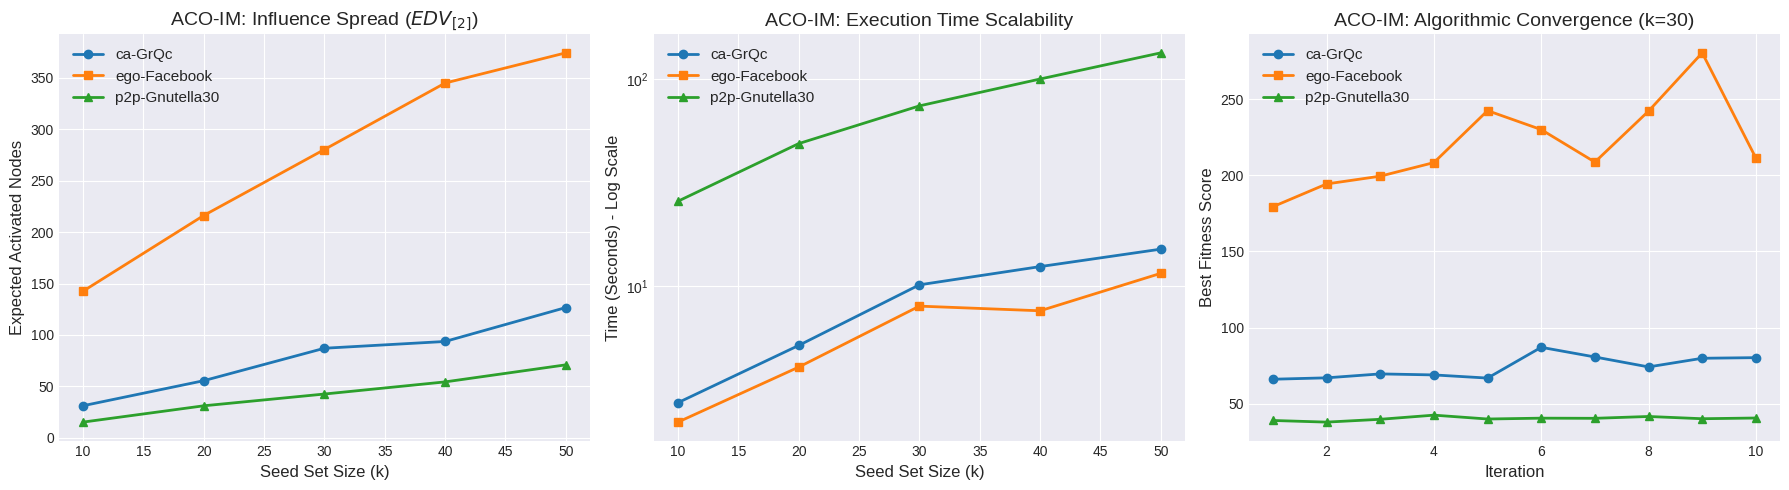

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math
import warnings
warnings.filterwarnings('ignore')

#EDV_2

def edv_2_fitness(G, S, p=0.1):
    """
    Calculates the Expected Diffusion Value within a 2-hop area.
    This mathematical heuristic replaces Monte Carlo simulations for extreme speed.
    """
    S_set = set(S)
    k = len(S_set)
    if k == 0: return 0

    # 1-Hop Neighbors
    N1 = set()
    for u in S_set:
        for v in G.successors(u):
            if v not in S_set:
                N1.add(v)

    # 2-Hop Neighbors
    N2 = set()
    for v in N1:
        for w in G.successors(v):
            if w not in S_set and w not in N1:
                N2.add(w)

    # 1-Hop Spread Calculation
    sigma_1 = 0
    for u in S_set:
        prob_failure = 1.0
        for v in G.successors(u):
            if v in N1:
                prob_failure *= (1 - p)
        sigma_1 += (1 - prob_failure)

    if len(N1) == 0:
        return k

    # 2-Hop Expansion Multiplier
    two_hop_sum = 0
    for w in N2:
        in_edges_from_N1 = sum(1 for v in G.predecessors(w) if v in N1)
        p_A_w = 1 - ((1 - p) ** in_edges_from_N1)
        two_hop_sum += (p_A_w * in_edges_from_N1)

    expansion_multiplier = 1 + (1 / len(N1)) * two_hop_sum
    return k + (expansion_multiplier * sigma_1)

#ACO

def run_aco_im(G, k, pop_size=20, I_max=15, rho=0.2, alpha=0.5, beta=0.5):
    """
    Constructs seed sets node-by-node using pheromone trails and heuristics.
    """
    all_nodes = list(G.nodes())
    tau = {node: 1.0 for node in all_nodes}

    best_spread = 0
    num_best = max(1, int(pop_size * 0.25)) # Top 25% ants drop pheromones
    convergence_history = []

    for I in range(1, I_max + 1):
        # Exploration decay probability (Eq. 11)
        p_I = math.log(I) / math.log(I_max) if I_max > 1 else 1.0
        ant_solutions = []

        for _ in range(pop_size):
            current_seed = []
            avail = set(all_nodes)

            while len(current_seed) < k:
                # Premature Convergence Avoidance
                if random.random() >= p_I:
                    selected = random.sample(list(avail), 1)[0]
                else:
                    # Heuristic selection based on pheromones (Eq. 9 & 10)
                    weights = []
                    nodes_list = list(avail)
                    for v in nodes_list:
                        eta_v = rho * tau[v]
                        weights.append((tau[v] ** alpha) * (eta_v ** beta))

                    tot_weight = sum(weights)
                    if tot_weight > 0:
                        probs = [w / tot_weight for w in weights]
                        selected = np.random.choice(nodes_list, p=probs)
                    else:
                        selected = random.sample(nodes_list, 1)[0]

                current_seed.append(selected)
                avail.remove(selected)

            ant_solutions.append(current_seed)

        # Evaluate fitness for the colony
        scores = [edv_2_fitness(G, sol) for sol in ant_solutions]
        current_max = max(scores)
        if current_max > best_spread:
            best_spread = current_max

        convergence_history.append(current_max)

        # Pheromone Update
        scored = list(zip(ant_solutions, scores))
        scored.sort(key=lambda x: x[1], reverse=True)
        S_best = scored[:num_best]

        for u in all_nodes:
            tau[u] *= (1 - rho) # Evaporate

        dep_mult = rho / I
        for sol, fit in S_best:
            for u in sol:
                tau[u] += dep_mult * fit # Deposit

    return best_spread, convergence_history


if __name__ == "__main__":
    print("Loading datasets into NetworkX...")
    # Load all three datasets as directed graphs
    datasets = {
        "ca-GrQc": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/CA-GrQc.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "ego-Facebook": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/facebook_combined.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "p2p-Gnutella30": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/p2p-Gnutella30.txt', create_using=nx.DiGraph(), nodetype=int, comments='#')
    }

    k_values = [10, 20, 30, 40, 50]

    # Dictionaries to store results
    res_spread = {name: [] for name in datasets.keys()}
    res_time = {name: [] for name in datasets.keys()}
    res_convergence = {name: [] for name in datasets.keys()}

    print("-" * 50)
    for name, G in datasets.items():
        print(f"Benchmarking ACO-IM on {name} (Nodes: {G.number_of_nodes()})...")

        # Run across all k values for Spread and Time metrics
        for k in k_values:
            start = time.time()
            # For efficiency in a notebook, we keep iterations lower (I_max=10)
            spread, convergence = run_aco_im(G, k=k, pop_size=15, I_max=10)
            elapsed = time.time() - start

            res_spread[name].append(spread)
            res_time[name].append(elapsed)

            # Save the convergence history specifically for k=30 to plot later
            if k == 30:
                res_convergence[name] = convergence

            print(f"  -> k={k:2d} | Spread: {spread:6.2f} | Time: {elapsed:5.2f}s")
    print("-" * 50)

    # GENERATING THE 3 GRAPHS
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['o', 's', '^']

    # 1. Spread Comparison Across Datasets
    for idx, name in enumerate(datasets.keys()):
        axes[0].plot(k_values, res_spread[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[0].set_title('ACO-IM: Influence Spread ($EDV_{[2]}$)', fontsize=14)
    axes[0].set_xlabel('Seed Set Size (k)', fontsize=12)
    axes[0].set_ylabel('Expected Activated Nodes', fontsize=12)
    axes[0].legend(fontsize=11)

    # 2. Time Comparison Across Datasets
    for idx, name in enumerate(datasets.keys()):
        axes[1].plot(k_values, res_time[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[1].set_title('ACO-IM: Execution Time Scalability', fontsize=14)
    axes[1].set_xlabel('Seed Set Size (k)', fontsize=12)
    axes[1].set_ylabel('Time (Seconds) - Log Scale', fontsize=12)
    axes[1].set_yscale('log') # Log scale is crucial for showing network size differences
    axes[1].legend(fontsize=11)

    # 3. Convergence Comparison (k=30)
    iterations = list(range(1, 11))
    for idx, name in enumerate(datasets.keys()):
        axes[2].plot(iterations, res_convergence[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[2].set_title('ACO-IM: Algorithmic Convergence (k=30)', fontsize=14)
    axes[2].set_xlabel('Iteration', fontsize=12)
    axes[2].set_ylabel('Best Fitness Score', fontsize=12)
    axes[2].legend(fontsize=11)

    plt.tight_layout()
    plt.show()

**PSO Model**

Loading datasets into NetworkX...
--------------------------------------------------
Benchmarking Discrete PSO on ca-GrQc (Nodes: 5242)...
  -> k=10 | Spread:  26.15 | Time:  0.20s
  -> k=20 | Spread:  49.94 | Time:  0.30s
  -> k=30 | Spread:  94.82 | Time:  0.32s
  -> k=40 | Spread:  90.11 | Time:  0.40s
  -> k=50 | Spread: 115.39 | Time:  0.43s
Benchmarking Discrete PSO on ego-Facebook (Nodes: 4039)...
  -> k=10 | Spread: 133.46 | Time:  0.72s
  -> k=20 | Spread: 222.21 | Time:  1.12s
  -> k=30 | Spread: 336.32 | Time:  1.22s
  -> k=40 | Spread: 332.34 | Time:  1.44s
  -> k=50 | Spread: 345.19 | Time:  1.59s
Benchmarking Discrete PSO on p2p-Gnutella30 (Nodes: 36682)...
  -> k=10 | Spread:  18.06 | Time:  0.92s
  -> k=20 | Spread:  32.87 | Time:  0.96s
  -> k=30 | Spread:  47.44 | Time:  1.04s
  -> k=40 | Spread:  59.89 | Time:  1.05s
  -> k=50 | Spread:  74.75 | Time:  0.83s
--------------------------------------------------


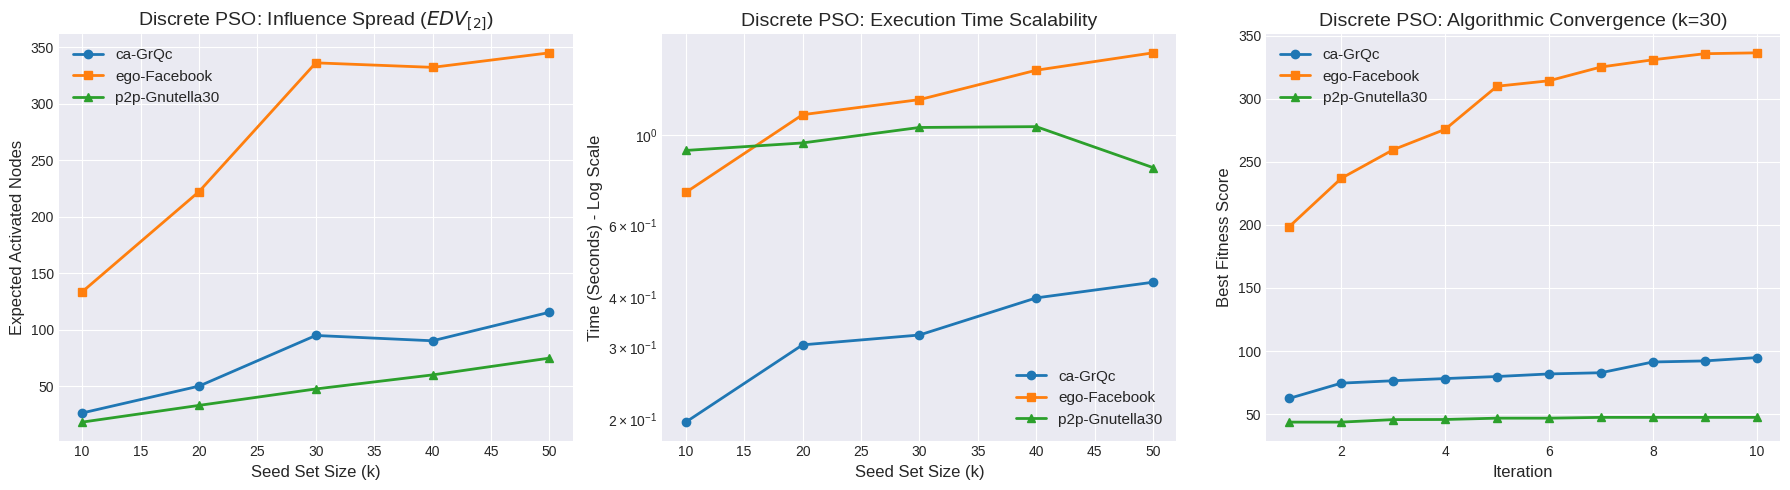

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import warnings
warnings.filterwarnings('ignore')

#EDV_2

def edv_2_fitness(G, S, p=0.1):
    """
    Calculates the Expected Diffusion Value within a 2-hop area.
    This mathematical heuristic replaces Monte Carlo simulations for extreme speed.
    """
    S_set = set(S)
    k = len(S_set)
    if k == 0: return 0

    # 1-Hop Neighbors
    N1 = set()
    for u in S_set:
        for v in G.successors(u):
            if v not in S_set:
                N1.add(v)

    # 2-Hop Neighbors
    N2 = set()
    for v in N1:
        for w in G.successors(v):
            if w not in S_set and w not in N1:
                N2.add(w)

    # 1-Hop Spread Calculation
    sigma_1 = 0
    for u in S_set:
        prob_failure = 1.0
        for v in G.successors(u):
            if v in N1:
                prob_failure *= (1 - p)
        sigma_1 += (1 - prob_failure)

    if len(N1) == 0:
        return k

    # 2-Hop Expansion Multiplier
    two_hop_sum = 0
    for w in N2:
        in_edges_from_N1 = sum(1 for v in G.predecessors(w) if v in N1)
        p_A_w = 1 - ((1 - p) ** in_edges_from_N1)
        two_hop_sum += (p_A_w * in_edges_from_N1)

    expansion_multiplier = 1 + (1 / len(N1)) * two_hop_sum
    return k + (expansion_multiplier * sigma_1)

#PSO

def run_discrete_pso(G, k, pop_size=15, I_max=10, w=0.7, c1=1.5, c2=1.5):
    """
    Discrete Particle Swarm Optimization (DPSO) for Influence Maximization.
    Uses continuous velocity vectors and a Sigmoid bridge to select discrete nodes.
    """
    all_nodes = np.array(list(G.nodes()))
    N = len(all_nodes)

    # Initialize velocities and positions
    velocities = np.random.uniform(-1, 1, (pop_size, N))
    positions = np.zeros((pop_size, N))
    for i in range(pop_size):
        positions[i, np.random.choice(N, k, replace=False)] = 1

    pbest_pos = np.copy(positions)
    pbest_scores = np.zeros(pop_size)

    gbest_pos = np.zeros(N)
    gbest_score = 0
    convergence_history = []

    for iteration in range(1, I_max + 1):
        # Evaluate fitness for the swarm
        for i in range(pop_size):
            sol = all_nodes[positions[i] == 1].tolist()
            score = edv_2_fitness(G, sol)

            # Update Personal Best
            if score > pbest_scores[i]:
                pbest_scores[i] = score
                pbest_pos[i] = np.copy(positions[i])

            # Update Global Best
            if score > gbest_score:
                gbest_score = score
                gbest_pos = np.copy(positions[i])

        convergence_history.append(gbest_score)

        # Update Velocities and Positions
        for i in range(pop_size):
            r1, r2 = np.random.rand(N), np.random.rand(N)

            # PSO Velocity Update Formula
            cognitive_pull = c1 * r1 * (pbest_pos[i] - positions[i])
            social_pull = c2 * r2 * (gbest_pos - positions[i])
            velocities[i] = (w * velocities[i]) + cognitive_pull + social_pull

            # The Sigmoid Transformation Bridge
            # np.clip prevents math overflow errors if velocities get too extreme
            clipped_vel = np.clip(velocities[i], -10, 10)
            probs = 1 / (1 + np.exp(-clipped_vel))

            # The Top-k Filter: Snap back to discrete choices
            top_k_indices = np.argsort(probs)[-k:]
            positions[i] = np.zeros(N)
            positions[i, top_k_indices] = 1

    return gbest_score, convergence_history


if __name__ == "__main__":
    print("Loading datasets into NetworkX...")
    datasets = {
        "ca-GrQc": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/CA-GrQc.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "ego-Facebook": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/facebook_combined.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "p2p-Gnutella30": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/p2p-Gnutella30.txt', create_using=nx.DiGraph(), nodetype=int, comments='#')
    }

    k_values = [10, 20, 30, 40, 50]

    # Dictionaries to store results
    res_spread = {name: [] for name in datasets.keys()}
    res_time = {name: [] for name in datasets.keys()}
    res_convergence = {name: [] for name in datasets.keys()}

    print("-" * 50)
    for name, G in datasets.items():
        print(f"Benchmarking Discrete PSO on {name} (Nodes: {G.number_of_nodes()})...")

        # Run across all k values for Spread and Time metrics
        for k in k_values:
            start = time.time()
            # For efficiency in a notebook, we keep iterations lower (I_max=10)
            spread, convergence = run_discrete_pso(G, k=k, pop_size=15, I_max=10)
            elapsed = time.time() - start

            res_spread[name].append(spread)
            res_time[name].append(elapsed)

            # Save the convergence history specifically for k=30 to plot later
            if k == 30:
                res_convergence[name] = convergence

            print(f"  -> k={k:2d} | Spread: {spread:6.2f} | Time: {elapsed:5.2f}s")
    print("-" * 50)

    # GENERATING THE 3 GRAPHS
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['o', 's', '^']

    # 1. Spread Comparison Across Datasets
    for idx, name in enumerate(datasets.keys()):
        axes[0].plot(k_values, res_spread[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[0].set_title('Discrete PSO: Influence Spread ($EDV_{[2]}$)', fontsize=14)
    axes[0].set_xlabel('Seed Set Size (k)', fontsize=12)
    axes[0].set_ylabel('Expected Activated Nodes', fontsize=12)
    axes[0].legend(fontsize=11)

    # 2. Time Comparison Across Datasets
    for idx, name in enumerate(datasets.keys()):
        axes[1].plot(k_values, res_time[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[1].set_title('Discrete PSO: Execution Time Scalability', fontsize=14)
    axes[1].set_xlabel('Seed Set Size (k)', fontsize=12)
    axes[1].set_ylabel('Time (Seconds) - Log Scale', fontsize=12)
    axes[1].set_yscale('log') # Log scale is crucial for showing network size differences
    axes[1].legend(fontsize=11)

    # 3. Convergence Comparison (k=30)
    iterations = list(range(1, 11))
    for idx, name in enumerate(datasets.keys()):
        axes[2].plot(iterations, res_convergence[name], marker=markers[idx], color=colors[idx], label=name, linewidth=2)
    axes[2].set_title('Discrete PSO: Algorithmic Convergence (k=30)', fontsize=14)
    axes[2].set_xlabel('Iteration', fontsize=12)
    axes[2].set_ylabel('Best Fitness Score', fontsize=12)
    axes[2].legend(fontsize=11)

    plt.tight_layout()
    plt.show()

**Combined Comparison**

Loading Datasets...
Benchmarking on Gnutella30 (Nodes: 36682)
  Evaluating k = 10...
  Evaluating k = 20...
  Evaluating k = 30...
  Evaluating k = 40...
  Evaluating k = 50...
Fetching Convergence Data on ego-Facebook...


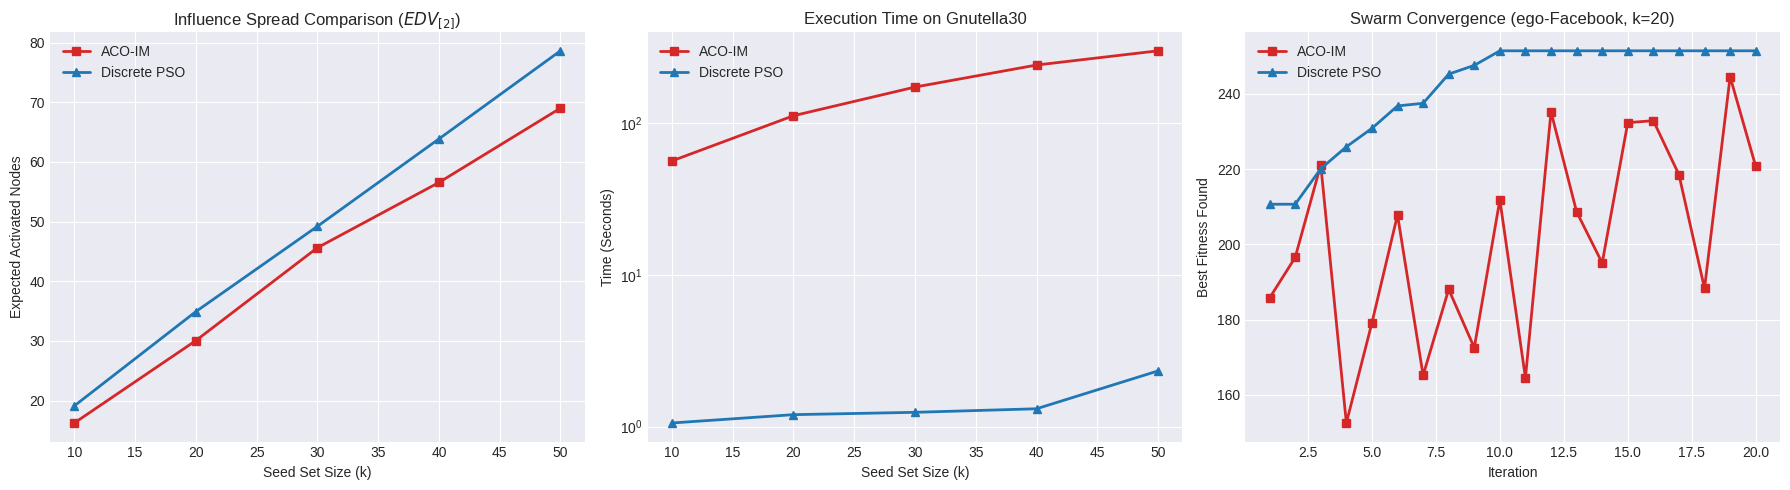

In [10]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math
import warnings
warnings.filterwarnings('ignore')

#EDV_2

def edv_2_fitness(G, S, p=0.1):
    """Calculates the Expected Diffusion Value within a 2-hop area."""
    S_set = set(S)
    k = len(S_set)
    if k == 0: return 0

    N1 = set()
    for u in S_set:
        for v in G.successors(u):
            if v not in S_set:
                N1.add(v)

    N2 = set()
    for v in N1:
        for w in G.successors(v):
            if w not in S_set and w not in N1:
                N2.add(w)

    sigma_1 = 0
    for u in S_set:
        prob_failure = 1.0
        for v in G.successors(u):
            if v in N1:
                prob_failure *= (1 - p)
        sigma_1 += (1 - prob_failure)

    if len(N1) == 0:
        return k

    two_hop_sum = 0
    for w in N2:
        in_edges_from_N1 = sum(1 for v in G.predecessors(w) if v in N1)
        p_A_w = 1 - ((1 - p) ** in_edges_from_N1)
        two_hop_sum += (p_A_w * in_edges_from_N1)

    expansion_multiplier = 1 + (1 / len(N1)) * two_hop_sum
    return k + (expansion_multiplier * sigma_1)

#ACO

def run_aco_im(G, k, pop_size=20, I_max=15, rho=0.2, alpha=0.5, beta=0.5):
    all_nodes = list(G.nodes())
    tau = {node: 1.0 for node in all_nodes}

    best_spread = 0
    num_best = max(1, int(pop_size * 0.25))
    convergence_history = []

    for I in range(1, I_max + 1):
        p_I = math.log(I) / math.log(I_max) if I_max > 1 else 1.0
        ant_solutions = []

        for _ in range(pop_size):
            current_seed = []
            avail = set(all_nodes)

            while len(current_seed) < k:
                if random.random() >= p_I:
                    selected = random.sample(list(avail), 1)[0]
                else:
                    # Heuristic selection
                    weights = []
                    nodes_list = list(avail)
                    for v in nodes_list:
                        eta_v = rho * tau[v]
                        weights.append((tau[v] ** alpha) * (eta_v ** beta))

                    tot_weight = sum(weights)
                    if tot_weight > 0:
                        probs = [w / tot_weight for w in weights]
                        # np.random.choice is faster than random.choices
                        selected = np.random.choice(nodes_list, p=probs)
                    else:
                        selected = random.sample(nodes_list, 1)[0]

                current_seed.append(selected)
                avail.remove(selected)

            ant_solutions.append(current_seed)

        scores = [edv_2_fitness(G, sol) for sol in ant_solutions]
        current_max = max(scores)
        if current_max > best_spread:
            best_spread = current_max

        convergence_history.append(current_max)

        # Pheromone Update
        scored = list(zip(ant_solutions, scores))
        scored.sort(key=lambda x: x[1], reverse=True)
        S_best = scored[:num_best]

        for u in all_nodes: tau[u] *= (1 - rho)
        dep_mult = rho / I
        for sol, fit in S_best:
            for u in sol: tau[u] += dep_mult * fit

    return best_spread, convergence_history

#PSO

def run_discrete_pso(G, k, pop_size=20, I_max=15, w=0.7, c1=1.5, c2=1.5):
    all_nodes = np.array(list(G.nodes()))
    N = len(all_nodes)

    velocities = np.random.uniform(-1, 1, (pop_size, N))
    positions = np.zeros((pop_size, N))
    for i in range(pop_size):
        positions[i, np.random.choice(N, k, replace=False)] = 1

    pbest_pos = np.copy(positions)
    pbest_scores = np.zeros(pop_size)
    gbest_pos = np.zeros(N)
    gbest_score = 0
    convergence_history = []

    for _ in range(1, I_max + 1):
        for i in range(pop_size):
            sol = all_nodes[positions[i] == 1].tolist()
            score = edv_2_fitness(G, sol)

            if score > pbest_scores[i]:
                pbest_scores[i] = score
                pbest_pos[i] = np.copy(positions[i])
            if score > gbest_score:
                gbest_score = score
                gbest_pos = np.copy(positions[i])

        convergence_history.append(gbest_score)

        for i in range(pop_size):
            r1, r2 = np.random.rand(N), np.random.rand(N)
            velocities[i] = (w * velocities[i]) + (c1 * r1 * (pbest_pos[i] - positions[i])) + (c2 * r2 * (gbest_pos - positions[i]))

            # Sigmoid & Top-k Filter
            probs = 1 / (1 + np.exp(-np.clip(velocities[i], -10, 10)))
            top_k = np.argsort(probs)[-k:]
            positions[i] = np.zeros(N)
            positions[i, top_k] = 1

    return gbest_score, convergence_history


if __name__ == "__main__":
    print("Loading Datasets...")
    datasets = {
        "ca-GrQc": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/CA-GrQc.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "ego-Facebook": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/facebook_combined.txt', create_using=nx.DiGraph(), nodetype=int, comments='#'),
        "p2p-Gnutella30": nx.read_edgelist('/content/drive/MyDrive/Explo Datasets/p2p-Gnutella30.txt', create_using=nx.DiGraph(), nodetype=int, comments='#')
    }

    k_values = [10, 20, 30, 40, 50] # Standard paper increments

    # We will plot the Spread and Time for the massive Gnutella dataset
    # and plot the Convergence on the Facebook dataset
    target_graph = datasets["p2p-Gnutella30"]
    print(f"Benchmarking on Gnutella30 (Nodes: {target_graph.number_of_nodes()})")

    res_spread = {"ACO": [], "PSO": []}
    res_time = {"ACO": [], "PSO": []}

    for k in k_values:
        print(f"  Evaluating k = {k}...")

        start = time.time()
        aco_spread, _ = run_aco_im(target_graph, k)
        res_time["ACO"].append(time.time() - start)
        res_spread["ACO"].append(aco_spread)

        start = time.time()
        pso_spread, _ = run_discrete_pso(target_graph, k)
        res_time["PSO"].append(time.time() - start)
        res_spread["PSO"].append(pso_spread)

    # Fetch convergence data specifically for the dense Facebook graph
    print("Fetching Convergence Data on ego-Facebook...")
    _, aco_conv = run_aco_im(datasets["ego-Facebook"], k=20, I_max=20)
    _, pso_conv = run_discrete_pso(datasets["ego-Facebook"], k=20, I_max=20)

    #GENERATING THE 3 GRAPHS
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Spread Comparison
    axes[0].plot(k_values, res_spread["ACO"], marker='s', color='#d62728', label='ACO-IM', linewidth=2)
    axes[0].plot(k_values, res_spread["PSO"], marker='^', color='#1f77b4', label='Discrete PSO', linewidth=2)
    axes[0].set_title('Influence Spread Comparison ($EDV_{[2]}$)')
    axes[0].set_xlabel('Seed Set Size (k)')
    axes[0].set_ylabel('Expected Activated Nodes')
    axes[0].legend()

    # 2. Time Comparison
    axes[1].plot(k_values, res_time["ACO"], marker='s', color='#d62728', label='ACO-IM', linewidth=2)
    axes[1].plot(k_values, res_time["PSO"], marker='^', color='#1f77b4', label='Discrete PSO', linewidth=2)
    axes[1].set_title('Execution Time on Gnutella30')
    axes[1].set_xlabel('Seed Set Size (k)')
    axes[1].set_ylabel('Time (Seconds)')
    axes[1].set_yscale('log')
    axes[1].legend()

    # 3. Convergence Comparison
    generations = list(range(1, 21))
    axes[2].plot(generations, aco_conv, marker='s', color='#d62728', label='ACO-IM', linewidth=2)
    axes[2].plot(generations, pso_conv, marker='^', color='#1f77b4', label='Discrete PSO', linewidth=2)
    axes[2].set_title('Swarm Convergence (ego-Facebook, k=20)')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Best Fitness Found')
    axes[2].legend()

    plt.tight_layout()
    plt.show()